# SENDAs Agreement 1 Update 2010-2022 (Prediction, step 2.2, shap-informed models)

This notebook was converted automatically from `prediction22.qmd`.

Quarto-specific YAML/options were preserved in the first raw cell. I also inserted setup cells at the beginning for project-root detection, loading `pred21_ndp_2026_03_26.Rdata`, plot sizing, and optional `renv` repair.


In [1]:
# --- Setup: project root, data load, plot size/resolution, and renv activation ---

# adjust plot size and resolution for high-quality output

# --- Load pred21_ndp_2026_03_26.Rdata (simple, project-root aware, no functions) --- 
# 1) Locate the file anywhere under the project root (current WD with a trailing "/cons" trimmed)
project_root <- sub("(/)?cons/?$", "", normalizePath(getwd(), winslash = "/", mustWork = FALSE))
fname        <- "pred21_ndp_2026_03_26.Rdata"
hits <- list.files(project_root, pattern = paste0("^", fname, "$"),
                   recursive = TRUE, full.names = TRUE, ignore.case = TRUE)

# If not found and path contains "Documents\GitHub\", try the data folder
if (!length(hits) && grepl("Documents[/\\\\]GitHub", project_root)) {
  alt_data_dir <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data")
  message("File not found in project root. Trying alternative data directory: ", alt_data_dir)
  hits <- list.files(alt_data_dir, pattern = paste0("^", fname, "$"),
                     recursive = TRUE, full.names = TRUE, ignore.case = TRUE)
}

if (!length(hits)) {
  stop("File not found: ", fname, 
       "\nSearched under: ", project_root,
       "\nAnd under: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data"))
}
path <- hits[1]  # take first match
message("Loading: ", path)

# 2) Load into a dedicated environment (keeps .GlobalEnv clean)
env_pred <- new.env(parent = emptyenv())
loaded_objects <- load(path, envir = env_pred)
message("Loaded ", length(loaded_objects), " object(s): ", paste(loaded_objects, collapse = ", "))

# 3) Quick sanity check for each loaded object
for (obj_name in loaded_objects) {
  obj <- get(obj_name, envir = env_pred)
  message("\n--- ", obj_name, " ---")
  if (is.data.frame(obj)) {
    message("Rows: ", nrow(obj), " | Cols: ", ncol(obj))
  } else {
    message("Class: ", paste(class(obj), collapse = ", "), " | Length/Size: ", length(obj))
  }
  # print(str(obj))
}

# 4) Extract all loaded objects to global environment
for (obj_name in loaded_objects) {
  assign(obj_name, get(obj_name, envir = env_pred), envir = .GlobalEnv)
}

# Clean up temporary environment
rm(env_pred)

options(jupyter.max_output_size = Inf)
options(repr.plot.width = 16 * 1.5, repr.plot.height = 12 * 1.5)
options(repr.plot.res = 300)

# --- renv activation with fallback ---
Sys.setenv(RENV_PROJECT = project_root)

# Try project_root renv first, then fallback to Documents/GitHub/renv
renv_activate <- file.path(project_root, "renv/activate.R")
if (!file.exists(renv_activate)) {
  # Fallback: construct path from USERPROFILE environment variable
  fallback_root <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub")
  renv_activate <- file.path(fallback_root, "renv/activate.R")
  
  if (file.exists(renv_activate)) {
    message("Project renv not found. Using fallback renv at: ", renv_activate)
    Sys.setenv(RENV_PROJECT = fallback_root)
  } else {
    stop("renv/activate.R not found at project root nor at fallback location: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/renv/activate.R"))
  }
}

source(renv_activate)

getwd()
Sys.getenv("RENV_PROJECT")
.libPaths()

Loading: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred21_ndp_2026_03_26.Rdata


by .GlobalEnv when processing object ‘cal_readmit2’
by .GlobalEnv when processing object ‘plot_cloglog_comb’
by .GlobalEnv when processing object ‘plot_cloglog_comb’
by .GlobalEnv when processing object ‘plot_cloglog_comb’
by .GlobalEnv when processing object ‘plot_cloglog_comb’


Loaded 281 object(s): infectious_set, find_latest_file, cal_readmit2, mode_pick_int, cal_readmit3, python_columns, nm, cal_death_full_ici, collapse_first_sub_used_other, .cph_boot_extract_ibs, char_variables, secret_file_path, cols_to_exclude, total_cpus, decrypt_column, n1b_cases, api_key, plot_cloglog_comb, encrypt_column, renviron_path, .mi_cv_build_level_mapping, subkey_to_label, hits, missing_pct, target_cols, py_split, aicc_death_upd2, dummy_formula, apply_ordered_mappings, t_grid, cif_d_before, m4_cases, calibrate_cph_grouped, m3_runs, violations, ph_test_death, root, ci_first, cal_readmit, existing_lines, obj, .Random.seed, n_before, results_readmit2_ibs, formula_readmit_updated2, decrypt_chr, DUMMY_REFERENCE, .mi_cv_normalize_call_name, pairs, key_exists, encrypt_chr, sum_dates_polars, normalize_txt, find_python_rel, .mi_cv_collect_strata_term_labels, time_before_dedup2, numerical_vars2, lab_first_index, print.cph_grouped_calibration, evaluate_mi_cv_safe_strata, var2_table, ci

[1] "G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32"              
[2] "C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43"

In [2]:
# Function to handle renv environment loading based on working directory rules
load_custom_renv <- function() {
  # Get current working directory
  wd <- getwd()
  
  # Normalize to lowercase for case-insensitive matching
  wd_lower <- tolower(wd)
  
  # Rule 1: If path contains "mi unidad" or "my drive"
  if (grepl("mi unidad", wd_lower) || grepl("my drive", wd_lower)) {
    message("Rule 1: Path is inside Google Drive. Keeping current environment.")
    
  # Rule 2: If path contains "cons"
  } else if (grepl("cons", wd_lower)) {
    parent_dir <- dirname(wd)
    lockfile <- file.path(parent_dir, "renv.lock")
    
    # Rule 3: Check if renv.lock exists in parent directory
    if (file.exists(lockfile)) {
      message("Rule 3: Found renv.lock in parent directory. Restoring environment...")
      renv::restore(lockfile = lockfile, exclude= "polars")
    } else {
      message("Rule 3: No renv.lock found in parent directory. No restore performed.")
    }
    
  # Default case: Path does not match any rule
  } else {
    message("Default: Path does not match rules. Keeping current environment.")
  }
}

# Example usage:
load_custom_renv()


Rule 1: Path is inside Google Drive. Keeping current environment.


In [3]:
# --- Optional renv cleanup / repair ---
# Run this only if you actually need to repair the project library.

unlink("renv/staging", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/geepack", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/V8", recursive = TRUE, force = TRUE)

renv::status()
#renv::restore(exclude = c("polars"))

No issues found -- the project is in a consistent state.


<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">


In [4]:
#| label: setup
#| results: "hold"
#renv falls back to copying rather than symlinking, which is evidently very slow in this configuration.
renv::settings$use.cache(FALSE)
#only use explicit dependencies (in DESCRIPTION)
renv::settings$snapshot.type("implicit")
#check if rstools is installed
if(Sys.info()["sysname"]=="Windows"){
try(installr::install.Rtools(check_r_update=F))
}
check_quarto_version <- function(required = "1.7.29", comparator = c("ge","gt","le","lt","eq")) {
  comparator <- match.arg(comparator)
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req     <- package_version(required)
  ok <- switch(comparator,
               ge = current >= req,
               gt = current >  req,
               le = current <= req,
               lt = current <  req,
               eq = current == req)
  if (!ok) {
    stop(sprintf("Quarto version check failed: need %s %s (installed: %s).",
                 comparator, required, current), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge") 
#change repository to CL
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos=r)
})
if(!require(pacman)){install.packages("pacman");require(pacman)}
if(!require(pak)){install.packages("pak");require(pak)}
pacman::p_unlock(lib.loc = .libPaths()) #para no tener problemas reinstalando paquetes
if(Sys.info()["sysname"]=="Windows"){
if (getRversion() != "4.4.1") { stop("Requires R version 4.4.1; Actual: ", getRversion()) }
}
#check docker
check_docker_running <- function() {
  # Try running 'docker info' to check if Docker is running
  system("docker info", intern = TRUE, ignore.stderr = TRUE)
}
if(Sys.info()["sysname"]=="Windows"){
  install_docker <- function() {
    # Open the Docker Desktop download page in the browser for installation
    browseURL("https://www.docker.com/products/docker-desktop")
  }
  # Main logic
  if (inherits(try(check_docker_running(), silent = TRUE), "try-error")) {
    liftr::install_docker()
  } else {
    message("Docker is running.")
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#PACKAGES#######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
unlink("*_cache", recursive=T)
pak::pak_sitrep()
# pak::sysreqs_check_installed(unique(unlist(paks)))
#pak::lockfile_create(unique(unlist(paks)),  "dependencies_duplicates24.lock", dependencies=T)
#pak::lockfile_install("dependencies_duplicates24.lock")
#https://rdrr.io/cran/pak/man/faq.html
#pak::cache_delete()
library(tidytable)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(caret)
library(dplyr)
library(survex)
library(pec)
library(future)
library(future.apply)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)

#flexsurv
#if(!require(compareCstat)){install.pacakges("compareCstat")}
# library(shapr)#https://norskregnesentral.github.io/shapr/
# library(SemiMarkov)#https://www.degruyterbrill.com/document/doi/10.1515/ijb-2020-0083/html?lang=en
# #https://www.jclinepi.com/article/S0895-4356(24)00142-2/fulltext
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 3. Activate polars code completion (safe to try even if it fails)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
#try(polars_code_completion_activate())
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 4. BPMN from GitHub (not on CRAN, so install via devtools if missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
if (!requireNamespace("bpmn", quietly = TRUE)) {
  devtools::install_github("bergant/bpmn")
}
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 5. PhantomJS Check (use webshot if PhantomJS is missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# if (!webshot::is_phantomjs_installed()) {
#   webshot::install_phantomjs()
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
pander::panderOptions('big.mark', ',')
pander::panderOptions('decimal.mark', '.')
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#to format rows in bold
format_cells <- function(df, rows ,cols, value = c("italics", "bold", "strikethrough")){
  # select the correct markup
  # one * for italics, two ** for bold
  map <- setNames(c("*", "**", "~~"), c("italics", "bold", "strikethrough"))
  markup <- map[value]  
  for (r in rows){
    for(c in cols){
      # Make sure values are not factors
      df[[c]] <- as.character( df[[c]])
      # Update formatting
      df[r, c] <- ifelse(nchar(df[r, c])==0,"",paste0(markup, gsub(" ", "", df[r, c]), markup))
    }
  }
  return(df)
}
#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
sum_dates <- function(x){
  cbind.data.frame(
    min= as.Date(min(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01"),
    p001= as.Date(quantile(unclass(as.Date(x)), .001, na.rm=T), origin = "1970-01-01"),
    p005= as.Date(quantile(unclass(as.Date(x)), .005, na.rm=T), origin = "1970-01-01"),
    p025= as.Date(quantile(unclass(as.Date(x)), .025, na.rm=T), origin = "1970-01-01"),
    p25= as.Date(quantile(unclass(as.Date(x)), .25, na.rm=T), origin = "1970-01-01"),
    p50= as.Date(quantile(unclass(as.Date(x)), .5, na.rm=T), origin = "1970-01-01"),
    p75= as.Date(quantile(unclass(as.Date(x)), .75, na.rm=T), origin = "1970-01-01"),
    p975= as.Date(quantile(unclass(as.Date(x)), .975, na.rm=T), origin = "1970-01-01"),
    p995= as.Date(quantile(unclass(as.Date(x)), .995, na.rm=T), origin = "1970-01-01"),
    p999= as.Date(quantile(unclass(as.Date(x)), .999, na.rm=T), origin = "1970-01-01"),
    max= as.Date(max(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01")
  )
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Define the function adapted for Polars
sum_dates_polars <- function(df, date_col) {
  # Create the list of quantiles
  quantiles <- c(0.001, 0.005, 0.025, 0.25, 0.5, 0.75, 0.975, 0.995, 0.999)
  # Create expressions to calculate min and max
  expr_list <- list(
    pl$col(date_col)$min()$alias("min"),
    pl$col(date_col)$max()$alias("max")
  )
  # Add expressions for quantiles
  for (q in quantiles) {
    expr_list <- append(expr_list, pl$col(date_col)$quantile(q)$alias(paste0("p", sub("\\.", "", as.character(q)))))
  }
  # Apply the expressions and return a DataFrame with the results
  df$select(expr_list)
}
# Custom function for sampling with a seed
sample_n_with_seed <- function(data, size, seed) {
  set.seed(seed)
  dplyr::sample_n(data, size)
}
# Function to get the most frequent value 
most_frequent <- function(x) { 
  uniq_vals <- unique(x)
  freq_vals <- sapply(uniq_vals, function(val) sum(x == val))
  most_freq <- uniq_vals[which(freq_vals == max(freq_vals))]
  
  if (length(most_freq) == 1) {
    return(most_freq)
  } else {
    return(NA)
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#CONFIG #######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
options(scipen=2) #display numbers rather scientific number
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# Define the function first
#joins these values with semicolons and optionally truncates the result if it exceeds a specified width.
toString2 <- function(x, width = NULL, ...) {
    string <- paste(x, collapse = "; ")
    if (missing(width) || is.null(width) || width == 0) 
        return(string)
    if (width < 0) 
        stop("'width' must be positive")
    if (nchar(string, type = "w") > width) {
        width <- max(6, width)
        string <- paste0(substr(string, 1, width - 3), "...")
    }
    string
}
normalize_txt <- function(x) {
  x|>
    stringi::stri_trans_general("Latin-ASCII")|>
    tolower()|>
    trimws()
}
pair_str <- function(main, sub) {
  main <- as.character(main)
  sub  <- as.character(sub)
  both_na <- is.na(main) & is.na(sub)
  out <- paste0(
    tidytable::coalesce(main, "NA"),
    "::",
    tidytable::coalesce(sub,  "NA")
  )
  out[both_na] <- NA_character_
  out
}
# ── Helpers ────────────────────────────────────────────────────────────
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Encryption ────────────────────────────────────────────────────────
# Pack: [24-byte nonce][ciphertext] -> hex
encrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        ct <- sodium::data_encrypt(charToRaw(as.character(v)), key)
        nonce <- attr(ct, "nonce")                 # 24 bytes
        sodium::bin2hex(c(nonce, ct))              # pack nonce + ct
    }, FUN.VALUE = character(1))
}
# Unpack: hex -> [nonce|ciphertext], restore attr(nonce), then decrypt
decrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        buf <- sodium::hex2bin(v)
        if (length(buf) < 25L) stop("Ciphertext too short or corrupted.")
        nonce <- buf[1:24]
        ct    <- buf[-(1:24)]
        attr(ct, "nonce") <- nonce
        rawToChar(sodium::data_decrypt(ct, key))
    }, FUN.VALUE = character(1))
}
# Function to encrypt a character vector
encrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item) || item == "") {
      return(NA_character_)
    }
    encrypted_raw <- sodium::data_encrypt(charToRaw(item), key)
    base64enc::base64encode(encrypted_raw)  # Convert to base64 for storage
  }, USE.NAMES = FALSE)
}
decrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item)) return(NA_character_)
    encrypted_raw <- base64enc::base64decode(item)
    rawToChar(sodium::data_decrypt(encrypted_raw, key))
  }, USE.NAMES = FALSE)
}
is_stata_ok <- function(x) {
  nchar(x) <= 32 & grepl("^[A-Za-z][A-Za-z0-9_]*$", x)
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Tidy RMS ────────────────────────────────────────────────────────
tidy_cph <- function(model) {
  if (!inherits(model, "cph")) stop("Model must be an rms::cph object")
  
  # run summary
  s <- summary(model)
  df_s <- as.data.frame(unclass(s))
  df_s$rown <- rownames(s)
  
  # find rows that are "Hazard Ratio"
  hr_rows <- trimws(df_s$rown) == "Hazard Ratio"
  
  # build tidy tibble
  tibble::tibble(
    term     = trimws(rownames(s)[which(hr_rows) - 1L]), # previous row = variable name
    estimate = df_s$Effect[hr_rows],                     # Hazard Ratio
    conf.low = df_s$`Lower 0.95`[hr_rows],
    conf.high= df_s$`Upper 0.95`[hr_rows],
    p.value  = df_s$P[hr_rows]
  )
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
find_latest_file <- function(project_root, prefix, extension = "csv") {
  # Construct the regex pattern using the provided extension.
  # We use \\. to match the literal dot before the extension.
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.", extension, "$")
  # List files matching the pattern recursively under the project root
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE,
    recursive = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern, "under", project_root))
  }
  # Helper to extract timestamps from filenames (expected format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    # Use the last match in case there are multiple date-like strings in the path
    return(matches[[1]][length(matches[[1]])])
  }
  # Compute timestamps for all found files
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in the matching filenames.")
  }
    # Sort by timestamp (descending) and return the latest file path
  # Lexicographical sorting works correctly for YYYYMMDD_HHMM format
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}

Installing package into ‘G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32’
(as ‘lib’ is unspecified)


trying URL 'https://packagemanager.posit.co/cran/latest/bin/windows/contrib/4.4/pkgbuild_1.4.8.zip'
Content type 'binary/octet-stream' length 211749 bytes (206 KB)
downloaded 206 KB



package ‘pkgbuild’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\andre\AppData\Local\Temp\Rtmp23HIbB\downloaded_packages
Loading required package: pkgbuild
No need to install Rtools - You've got the relevant version of Rtools installed
Loading required package: pacman
Loading required package: pak

No 00LOCK detected in:
 G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
No 00LOCK detected in:
 C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
Docker is running.


Warning message:
In system("docker info", intern = TRUE, ignore.stderr = TRUE) :
  running command 'docker info' had status 1


* pak version:
- 0.8.0.1
* Version information:
- pak platform: x86_64-w64-mingw32 (current: x86_64-w64-mingw32, compatible)
- pak repository: - (local install?)
* Optional packages installed:
- pillar
* Library path:
- G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
- C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
* pak is installed at G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32/pak.
* Dependency versions:
- callr       3.7.6      
- cli         3.6.2      
- curl        5.2.1      
- desc        1.4.3      
- desktop.ini NA         
- filelock    1.0.3      
- jsonlite    1.8.8      
- lpSolve     5.6.23.9000
- pkgbuild    1.4.4      
- pkgcache    2.2.2.9000 
- pkgdepends  0.7.2.9000 
- pkgsearch   3.1.3.9000 
- processx    3.8.4      
- ps          1.7.6      
- R6          2.5.1      
- zip         2.3.1      
* Dependencies can be loaded

Attaching package: ‘tidytabl

In [5]:

root <- here::here()

project_root <- gsub("/cons$", "", root) 

data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")


<br>

::: {.callout-note}
**Aims**
- To identify key prognostic and predictive factors associated with the risk of, and time to, the first readmission to treatment among patients aged 18-64 undergoing initial treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
- To identify key prognostic and predictive factors associated with the risk of, and time to, all-cause mortality among the same cohort of patients undergoing initial treatment for SUD in Chile.
- To predict the risk and timing of first treatment readmission and all-cause mortality simultaneously, treating these outcomes within a semi-competing risks framework. This will allow for the estimation of cumulative incidence for each event in the presence of the other for patients aged 18-64 who initiated SUD treatment in Chile between 2010 and 2020.
This study has three primary objectives. First, we aim to identify key prognostic and predictive factors associated with the risk and timing of two critical outcomes: (i) first readmission to treatment and (ii) all-cause mortality. Second, using a semi-competing risks framework, we will develop a model to simultaneously predict these two outcomes, accounting for the fact that death precludes the possibility of readmission. Finally, this model will be used to estimate the probability of various patient trajectories over time following initial treatment. The study population includes all patients aged 18-64 who began treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
:::
<br>



In [6]:
#| label: shap-criteria-setup

gc()

total_cpus <- parallel::detectCores()
cpus <- ifelse(total_cpus > 30, 16, 7)

predictor_tiers <- readxl::read_excel(
  file.path(project_root, "cons", "_out",
            "xgb9_dual_predictor_analysis_no_clinical_20260306_1821.xlsx"),
  sheet = "Predictors"
) |>
  dplyr::filter(!grepl("MINOR",importance_tier))


predictor_tiers |> knitr::kable(
  caption = "Predictor tiers based on SHAP importance from XGBoost models"
)




Table: Predictor tiers based on SHAP importance from XGBoost models

|outcome     |feature                                       | mean_abs_shap_log_hazard| rank| rel_to_max_pct|importance_tier       | mean_rank| cv_rank_pct| rank_ci2p5| rank_ci97p5| freq_in_top_45_pct|stable_freq_ge_90pct |direction_method     | delta_point| delta_ci_low| delta_ci_high| direction_n|direction_label |
|:-----------|:---------------------------------------------|------------------------:|----:|--------------:|:---------------------|---------:|-----------:|----------:|-----------:|------------------:|:--------------------|:--------------------|-----------:|------------:|-------------:|-----------:|:---------------|
|Readmission |primary_sub_mod_cocaine_paste                 |                0.0900146|    1|      100.00000|DOMINANT (>=50% max)  |     1.000|   0.0000000|      1.000|     1.00000|                100|TRUE                 |binary_x1_minus_x0   |   0.1847968|    0.1843984|     0.1851865|      

In [7]:
#| label: shap-criteria-defining-formula-w-predictors

gc()

options(future.globals.maxSize = 8L * 1024^3)  # 8 GiB

# # Linear time interaction
# coxph(Surv(time, death) ~ var + var:time + other_covariates, data = df)
# # Log-time interaction
# coxph(Surv(time, death) ~ var + var:log(time) + other_covariates, data = df)
# # Step function at 1 year (365 days)
# df$late_period <- as.numeric(df$time > 365)
# coxph(Surv(time, death) ~ var + var:late_period + other_covariates, data = df)
# # Using splines (requires splines package)
# library(splines)
# coxph(Surv(time, death) ~ var + var:ns(time, df=3) + other_covariates, data = df)
vars_shap_r <- c(
  "primary_sub_mod_cocaine_paste",
  "adm_age_rec3",
  "porc_pobr",
  "sex_rec_woman",
  #"plan_type_corr_pg_pr", # Mantenido en el código como strata()
  #"plan_type_corr_m_pr",  # Mantenido en el código como strata()
  "ethnicity",
  "dit_m",
  #"eva_consumo",
  "eva_consumo_logro_intermedio",
  "eva_consumo_logro_minimo",
  #"ed_attainment_corr",
  "ed_attainment_corr_2_completed_high_school_or_less",
  "ed_attainment_corr_3_completed_primary_school_or_less",
  "sub_dep_icd10_status_drug_dependence",
  "occupation_condition_corr24_unemployed",
  "polysubstance_strict",
  "primary_sub_mod_cocaine_powder",
  #"evaluacindelprocesoteraputico",
  "evaluacindelprocesoteraputico_logro_intermedio",
  "evaluacindelprocesoteraputico_logro_minimo", 
  "dg_psiq_cie_10_dg",
  "tr_outcome_adm_discharge_rule_violation_undet",
  #"eva_sm",
  "eva_sm_logro_intermedio",
  "eva_sm_logro_minimo",   
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP) ---
  #"adm_motive_justice_sector",
  #"tenure_status_household_others",
  #"tenure_status_household_renting",
  #"tenure_status_household_stays_temporarily_with_a_relative",
  #"tenure_status_household_illegal_settlement",
  #"tr_outcome_referral",
  #"eva_ocupacion_logro_intermedio",
  #"eva_ocupacion_logro_minimo",   
  #"eva_transgnorma_logro_intermedio",
  #"eva_transgnorma_logro_minimo",    
  
  #"prim_sub_freq_rec",
  "prim_sub_freq_rec_2_2_6_days_wk",
  "prim_sub_freq_rec_3_daily",  
  
  # --- NO LONGER IN TOP 20 MORTALITY  (SHAP) ---
  #"cohabitation_with_couple_children",
  
  "primary_sub_mod_alcohol"
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP) ---
  #"eva_relinterp_logro_intermedio",
  #"eva_relinterp_logro_minimo",  
  #"tr_outcome_dropout",
  #"dx_f6_personality",
  #"any_phys_dx",
  #"any_violence_1_domestic_violence_sex_abuse",
  #"adm_motive_sanitary_sector",
  #"eva_fam_logro_intermedio",
  #"eva_fam_logro_minimo"
)

vars_shap_d <- c(
  "adm_age_rec3",
  "primary_sub_mod_cocaine_paste",
  #"prim_sub_freq_rec", 
  "prim_sub_freq_rec_2_2_6_days_wk",
  "prim_sub_freq_rec_3_daily",
  
  # --- NO LONGER IN TOP 20 MORTALITY (SHAP 18:22) ---
  #"primary_sub_mod_cocaine_powder",
  
  "occupation_condition_corr24_unemployed",
  "any_phys_dx",
  #"eva_ocupacion",
  "eva_ocupacion_logro_intermedio",
  "eva_ocupacion_logro_minimo",  
  "first_sub_used_alcohol",
  "sex_rec_woman",
  #"eva_fisica"
  "eva_fisica_logro_intermedio",
  "eva_fisica_logro_minimo"
)
formula_shap_readmit <- as.formula(
  paste("Surv(readmit_time_from_disch_m, readmit_event) ~", 
        paste(vars_shap_r, collapse = " + "), "+ strata(plan_type_strata)")
)
formula_shap_death <- as.formula(
  paste("Surv(death_time_from_disch_m, death_event) ~", 
        paste(vars_shap_d, collapse = " + "), "+ strata(plan_type_strata)")
)

cat("Removing collineal variable\n")
formula_shap_readmit_clean <- as.formula(
  paste(gsub("evaluacindelprocesoteraputico_logro_minimo \\+\\s*","",paste(deparse(formula_shap_readmit), collapse = " "))))


Removing collineal variable


In [8]:
formula_shap_readmit_clean

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    adm_age_rec3 + porc_pobr + sex_rec_woman + ethnicity + dit_m + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    sub_dep_icd10_status_drug_dependence + occupation_condition_corr24_unemployed + 
    polysubstance_strict + primary_sub_mod_cocaine_powder + evaluacindelprocesoteraputico_logro_intermedio + 
    dg_psiq_cie_10_dg + tr_outcome_adm_discharge_rule_violation_undet + 
    eva_sm_logro_intermedio + eva_sm_logro_minimo + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + primary_sub_mod_alcohol + strata(plan_type_strata)

In [9]:
formula_shap_death

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    occupation_condition_corr24_unemployed + any_phys_dx + eva_ocupacion_logro_intermedio + 
    eva_ocupacion_logro_minimo + first_sub_used_alcohol + sex_rec_woman + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + strata(plan_type_strata)

In [10]:
#| label: shap-criteria-run-ev-mi-cv

results_readmit_shap <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_readmit_clean, 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20
)

results_death_shap <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_death, 
  imputed_list = py_corrected_datasets, 
  time_col = "death_time_from_disch_m", 
  event_col = "death_event",
  k = 5,
  n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...
Registered S3 methods overwritten by 'callr':
  method                    from
  format.callr_status_error     
  print.callr_status_error      

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6058 (repeat-quantile interval 0.6056-0.6061)
Pooled UnoC (survAUC::UnoC): 0.6784 (repeat-quantile interval 0.6473-0.6962)
Pooled IBS: 0.1602 (repeat-quantile interval 0.1601-0.1602)
Pooled IBS (IPCW-train): 0.3481 (repeat-quantile interval 0.3479-0.3483)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6294 (repeat-quantile interval 0.6291-0.6296, valid repeats=20)
  t=36 m: C=0.6135 (repeat-quantile interval 0.6133-0.6138, valid repeats=20)
  t=60 m: C=0.6087 (repeat-quantile in

In [11]:
dplyr::bind_rows(
  rms::vif(survival::coxph(formula_shap_death, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::arrange(dplyr::desc(dplyr::pick(2)[[1]])) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Death"),
  rms::vif(survival::coxph(formula_shap_readmit, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Readmission")
) |>
  knitr::kable("markdown", caption = "GVIF for SHAP-based Cox models, using one imputed dataset")




Table: GVIF for SHAP-based Cox models, using one imputed dataset

|Variable                                   |     Gvif|Outcome     |
|:------------------------------------------|--------:|:-----------|
|evaluacindelprocesoteraputico_logro_minimo | 10.64565|Readmission |

In [12]:
#| label: shap-criteria-source-python-style-dual-cox-eval

source(paste0(project_root,"/cons/_alt_scripts/evaluate_dual_cox_python_style_boot.R"))

In [92]:
#| label: full-criteria-run-ev-mi-cv-python-style

results_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit,
  formula_death = formula_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(6, 12, 36, 60, 108)
)


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [93]:
#| label: full-criteria-run-ev-mi-cv-python-style-print

results_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      |          |          |          |          |  0|
|Readmission |IBS           |12     | 0.2245764| 0.0096796| 0.2057025| 0.2389061| 25|
|Readmission |IBS           |36     | 0.2987614| 0.0088717| 0.2790217| 0.3111036| 25|
|Readmission |IBS           |60     | 0.3349380| 0.0082207| 0.3164983| 0.3454536| 25|
|Readmission |IBS           |Global | 0.3599762| 0.0080639| 0.3428948| 0.3707937| 25|
|Readmission |Uno's C-Index |6      | 0.6387528| 0.0076600| 0.6279513| 0.6502240| 25|
|Readmission |Uno's C-Index |12     | 0.6286369| 0.0056121| 0.6179003| 0.6373916| 25|
|Readmission |Uno's C-Index |36     | 0.6144891| 0.0040902| 0.6077019| 0.6211593| 25|
|Readmission |Uno's C-Index |60     | 0.6096573| 0.0041555| 0.6035531| 0.6175576| 25|
|Readmission 

In [94]:
#| label: full-criteria-upd-run-ev-mi-cv-python-style

results_upd_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated,
  formula_death = formula_death_updated,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(6, 12, 36, 60, 108)
)


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [95]:
#| label: full-criteria-upd-run-ev-mi-cv-python-style-print

results_upd_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      |          |          |          |          |  0|
|Readmission |IBS           |12     | 0.2245721| 0.0096783| 0.2056990| 0.2388995| 25|
|Readmission |IBS           |36     | 0.2987526| 0.0088660| 0.2790234| 0.3110940| 25|
|Readmission |IBS           |60     | 0.3349261| 0.0082119| 0.3165029| 0.3454609| 25|
|Readmission |IBS           |Global | 0.3599594| 0.0080516| 0.3428958| 0.3707569| 25|
|Readmission |Uno's C-Index |6      | 0.6388001| 0.0076951| 0.6279740| 0.6504659| 25|
|Readmission |Uno's C-Index |12     | 0.6286976| 0.0056091| 0.6179932| 0.6374001| 25|
|Readmission |Uno's C-Index |36     | 0.6145609| 0.0041140| 0.6077500| 0.6213650| 25|
|Readmission |Uno's C-Index |60     | 0.6097046| 0.0041880| 0.6035673| 0.6177471| 25|
|Readmission 

In [96]:
#| label: full-criteria-upd2-run-ev-mi-cv-python-style

results_upd2_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated2,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(6, 12, 36, 60, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [97]:
#| label: full-criteria-upd2-run-ev-mi-cv-python-style-print

results_upd2_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      |          |          |          |          |  0|
|Readmission |IBS           |12     | 0.2245721| 0.0096783| 0.2056990| 0.2388995| 25|
|Readmission |IBS           |36     | 0.2987526| 0.0088660| 0.2790234| 0.3110940| 25|
|Readmission |IBS           |60     | 0.3349261| 0.0082119| 0.3165029| 0.3454609| 25|
|Readmission |IBS           |Global | 0.3599594| 0.0080516| 0.3428958| 0.3707569| 25|
|Readmission |Uno's C-Index |6      | 0.6388001| 0.0076951| 0.6279740| 0.6504659| 25|
|Readmission |Uno's C-Index |12     | 0.6286976| 0.0056091| 0.6179932| 0.6374001| 25|
|Readmission |Uno's C-Index |36     | 0.6145609| 0.0041140| 0.6077500| 0.6213650| 25|
|Readmission |Uno's C-Index |60     | 0.6097046| 0.0041880| 0.6035673| 0.6177471| 25|
|Readmission 

In [13]:
#| label: shap-criteria-run-ev-mi-cv-python-style

results_shap_xgb_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean,
  formula_death = formula_shap_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [14]:
#| label: shap-criteria-summ-ev-mi-cv-python-style

results_shap_xgb_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519700| 0.0090251| 0.1371402| 0.1661768| 25|
|Readmission |IBS           |12     | 0.2026138| 0.0094830| 0.1855246| 0.2158807| 25|
|Readmission |IBS           |36     | 0.2940286| 0.0088744| 0.2747617| 0.3065304| 25|
|Readmission |IBS           |60     | 0.3311826| 0.0082261| 0.3136784| 0.3414768| 25|
|Readmission |IBS           |Global | 0.3584311| 0.0077723| 0.3430875| 0.3688206| 25|
|Readmission |Uno's C-Index |6      | 0.6412480| 0.0081244| 0.6296444| 0.6539760| 25|
|Readmission |Uno's C-Index |12     | 0.6295255| 0.0053438| 0.6198983| 0.6379025| 25|
|Readmission |Uno's C-Index |36     | 0.6135688| 0.0040008| 0.6067194| 0.6202294| 25|
|Readmission |Uno's C-Index |60     | 0.6088133| 0.0043228| 0.6027958| 0.6172611| 25|
|Readmission 

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 
Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


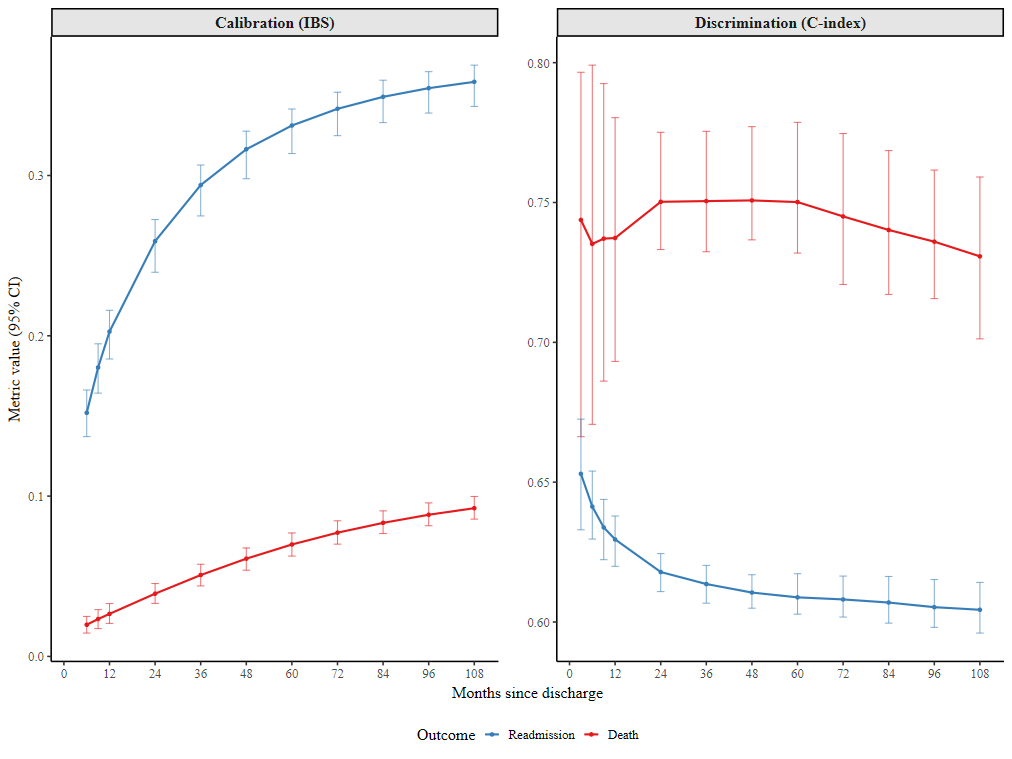

In [15]:
#| label: shap-criteria-dual-cox-plot-python-style-plot-by-time

tnr <- "Times New Roman"
set1_colors <- RColorBrewer::brewer.pal(n = 3, name = "Set1") # Set1 has up to 9 colors, but you only need 2
set1_colors <- rev(set1_colors[1:2])

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_xgb_py$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% filter(Metric == "IBS")


p_faceted <- time_metrics %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted

In [16]:
#| label: shap-criteria2

gc()
future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 10 * 1024^3
)
options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB

results_readmit_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_readmit_clean,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_death,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)

aicc_readmit_shap <- compute_mi_aicc(formula_shap_readmit_clean, py_corrected_datasets)#282719.30
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_shap$mean_aic - aicc_readmit_upd2$mean_aic))
#Difference in Mean AIC: 10170.15
aicc_death_shap <- compute_mi_aicc(formula_shap_death, py_corrected_datasets)
#54321.99
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_death_shap$mean_aic - aicc_death_upd2$mean_aic))
#Difference in Mean AIC: 2825.75
cat("Comparing readmission w/o collinear var and only one strata(plan)\n")
compare_mi_models_d1(formula_readmit_updated,formula_shap_readmit_clean, py_corrected_datasets)

compare_mi_models_d1(formula_death_updated,formula_shap_death, py_corrected_datasets)

Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3480 (95% CI: 0.3359 - 0.3610)
Valid bootstrap replicates: 500 / 500
Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0903 (95% CI: 0.0837 - 0.0974)
Valid bootstrap replicates: 500 / 500

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  282719.24
Mean AICc: 282719.30
Correction added (Penalty): 0.066474
Parameters (k): 22 | Effective Sample Size (Events): 15247

Difference in Mean AIC: 10170.15

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  54321.89
Mean AICc: 54321.99
Correction added (Penalty): 0.103106
Parameters (k): 12 | Effective Sample Size (Events): 3039

Difference in Mean AIC: 2825.75
Comparing readmission w/o collinear var and only on

In [17]:
calibrate_cph_grouped_corr <- function(
    formula,
    data,
    times = c(12, 36, 60),
    n_imputations = NULL,
    validation = c("apparent", "cv"),
    folds = 5L,
    n_repeats = 10L,
    g = 10L,
    min_bin_n = 20L,
    compute_ici = FALSE,
    ici_times = NULL,
    ici_df = 4L,
    seed = 2125L,
    ties = "efron",
    verbose = TRUE,
    make_plots = FALSE,
    parallel_cv = TRUE,
    future_scheduling = 2,
    debug_fit = FALSE
) {
    if (!requireNamespace("survival", quietly = TRUE)) {
        stop("Package 'survival' is required.")
    }
    if (isTRUE(compute_ici) && !requireNamespace("splines", quietly = TRUE)) {
        stop("Package 'splines' is required when compute_ici = TRUE.")
    }
    if (isTRUE(make_plots) && !requireNamespace("ggplot2", quietly = TRUE)) {
        stop("Package 'ggplot2' is required when make_plots = TRUE.")
    }
    if (!inherits(formula, "formula")) stop("'formula' must be a formula.")

    validation <- match.arg(validation)

    if (!is.numeric(times) || length(times) == 0L || any(!is.finite(times)) || any(times < 0)) {
        stop("'times' must be a non-empty numeric vector of non-negative finite values.")
    }

    times <- sort(unique(as.numeric(times)))
    folds <- as.integer(folds)
    n_repeats <- as.integer(n_repeats)
    g <- as.integer(g)
    min_bin_n <- as.integer(min_bin_n)
    ici_df <- as.integer(ici_df)
    parallel_cv <- isTRUE(parallel_cv)

    if (is.null(ici_times)) {
        ici_times <- times
    } else {
        if (!is.numeric(ici_times) || any(!is.finite(ici_times))) {
            stop("'ici_times' must be numeric.")
        }
        ici_times <- sort(unique(as.numeric(ici_times)))
    }

    if (any(!ici_times %in% times)) stop("'ici_times' must be a subset of 'times'.")
    if (validation == "cv" && folds < 2L) stop("'folds' must be >= 2 when validation = 'cv'.")
    if (n_repeats < 1L) stop("'n_repeats' must be >= 1.")
    if (g < 1L) stop("'g' must be >= 1.")
    if (min_bin_n < 1L) stop("'min_bin_n' must be >= 1.")
    if (ici_df < 1L) stop("'ici_df' must be >= 1.")

    if (validation == "apparent" && n_repeats != 1L) {
        if (isTRUE(verbose)) {
            message("validation = 'apparent': using a single run and ignoring n_repeats > 1.")
        }
        n_repeats <- 1L
    }

    .msg <- function(...) {
        if (isTRUE(verbose)) message(...)
    }

    .run_stats <- function(x, probs = c(0.025, 0.975), type = 8) {
        x <- x[is.finite(x)]
        n <- length(x)
        if (n == 0L) {
            return(c(
                mean = NA_real_, sd = NA_real_, min = NA_real_,
                p025 = NA_real_, p975 = NA_real_, max = NA_real_, n = 0L
            ))
        }
        q <- stats::quantile(x, probs = c(0, probs, 1), na.rm = TRUE, names = FALSE, type = type)
        c(
            mean = mean(x),
            sd = if (n > 1L) stats::sd(x) else 0,
            min = q[1],
            p025 = q[2],
            p975 = q[3],
            max = q[4],
            n = n
        )
    }

    .qualify_survival_formula_helpers <- function(formula_obj) {
        f_txt <- paste(deparse(formula_obj, width.cutoff = 500L), collapse = " ")

        f_txt <- gsub(
            "(?<![:[:alnum:]_])Surv\\s*\\(",
            "survival::Surv(",
            f_txt,
            perl = TRUE
        )

        f_txt <- gsub(
            "(?<![:[:alnum:]_])strata\\s*\\(",
            "survival::strata(",
            f_txt,
            perl = TRUE
        )

        f_txt
    }

    .parse_surv_formula <- function(formula_obj) {
        surv_call <- formula_obj[[2]]

        if (!inherits(surv_call, "call")) {
            stop("Formula must have a Surv() response.")
        }

        surv_fun <- paste(deparse(surv_call[[1]]), collapse = "")

        if (!(surv_fun %in% c("Surv", "survival::Surv"))) {
            stop("Formula must have a Surv() response variable.")
        }

        if (length(surv_call) != 3L) {
            stop("This function supports only right-censored Surv(time, event) formulas.")
        }

        list(
            time_var  = as.character(surv_call[[2]]),
            event_var = as.character(surv_call[[3]])
        )
    }

    .rhs_formula <- function(formula_obj) {
        f_rhs <- stats::formula(stats::delete.response(stats::terms(formula_obj)))
        environment(f_rhs) <- environment(formula_obj)
        f_rhs
    }

    .as_df_list <- function(x, n_imputations = NULL) {
        if (is.data.frame(x)) {
            out <- list(as.data.frame(x))
        } else if (is.list(x) && length(x) > 0L && all(vapply(x, is.data.frame, logical(1)))) {
            out <- lapply(x, as.data.frame)
        } else {
            stop("'data' must be a data.frame or a list of data.frames.")
        }
        if (!is.null(n_imputations)) {
            out <- out[seq_len(min(as.integer(n_imputations), length(out)))]
        }
        out
    }

    .coerce_event01 <- function(x, varname) {
        if (is.logical(x)) return(as.integer(x))
        if (is.factor(x)) x <- as.character(x)

        if (is.character(x)) {
            out <- rep(NA_integer_, length(x))
            ok <- !is.na(x)
            x0 <- trimws(tolower(x[ok]))
            out_ok <- ifelse(
                x0 %in% c("1", "true", "yes", "y"), 1L,
                ifelse(x0 %in% c("0", "false", "no", "n"), 0L, NA_integer_)
            )
            bad_nonmissing <- is.na(out_ok)
            if (any(bad_nonmissing)) {
                bad_vals <- unique(x[ok][bad_nonmissing])
                stop(
                    "Variable '", varname,
                    "' contains non-missing values that cannot be coerced to 0/1: ",
                    paste(utils::head(bad_vals, 10), collapse = ", ")
                )
            }
            out[ok] <- out_ok
            return(out)
        }

        if (is.numeric(x) || is.integer(x)) {
            ux <- unique(stats::na.omit(x))
            if (!all(ux %in% c(0, 1))) {
                stop("Variable '", varname, "' must contain only 0/1 values (besides NA).")
            }
            return(as.integer(x))
        }

        stop("Variable '", varname, "' must be logical, numeric/integer 0/1, factor, or character.")
    }

    .prepare_survival_data <- function(d, time_var, event_var) {
        req <- c(time_var, event_var)
        miss <- setdiff(req, names(d))
        if (length(miss) > 0L) stop("Missing required columns: ", paste(miss, collapse = ", "))

        tt <- d[[time_var]]
        ee <- .coerce_event01(d[[event_var]], event_var)

        if (!is.numeric(tt)) stop("Time variable must be numeric.")
        if (any(tt < 0, na.rm = TRUE)) stop("Negative follow-up times are not allowed.")

        d$.ftime <- tt
        d$.status <- ee
        d
    }

    .analysis_mask <- function(d0, rhs_formula, time_var, event_var) {
        mf_rhs <- stats::model.frame(rhs_formula, data = d0, na.action = stats::na.pass)
        stats::complete.cases(d0[, c(time_var, event_var, ".ftime", ".status"), drop = FALSE]) &
            stats::complete.cases(mf_rhs)
    }

    .validate_analysis_data <- function(dcc, validation, folds) {
        n <- nrow(dcc)
        n_events <- sum(dcc$.status == 1L, na.rm = TRUE)

        if (n == 0L) stop("No complete cases remain after unified filtering.")
        if (n_events < 1L) stop("No events remain in the analysis cohort.")

        if (validation == "cv") {
            if (folds > n) stop("'folds' cannot exceed the analysis sample size.")
            if (n_events < 2L) stop("Cross-validation is not feasible: fewer than 2 events remain.")
        }

        invisible(TRUE)
    }

    .make_stratified_folds <- function(status, folds, seed_local) {
        set.seed(seed_local)
        n <- length(status)
        if (folds > n) stop("'folds' cannot exceed sample size.")

        fold_id <- integer(n)
        classes <- sort(unique(status))
        offset <- 0L

        for (cl in classes) {
            idx <- which(status == cl)
            idx <- sample(idx, length(idx), replace = FALSE)
            assign <- ((seq_along(idx) - 1L + offset) %% folds) + 1L
            fold_id[idx] <- assign
            offset <- (offset + length(idx)) %% folds
        }

        tab <- tabulate(fold_id, nbins = folds)
        while (any(tab == 0L)) {
            empty_fold <- which(tab == 0L)[1L]
            donor_fold <- which.max(tab)
            donor_idx <- which(fold_id == donor_fold)
            move_idx <- sample(donor_idx, 1L)
            fold_id[move_idx] <- empty_fold
            tab <- tabulate(fold_id, nbins = folds)
        }

        for (k in seq_len(folds)) {
            tr_status <- status[fold_id != k]
            if (sum(tr_status == 1L, na.rm = TRUE) == 0L) {
                stop("Invalid fold split: training fold ", k, " has zero events.")
            }
            if (sum(fold_id == k) == 0L) {
                stop("Invalid fold split: test fold ", k, " is empty.")
            }
        }

        fold_id
    }
    .fit_cox_and_predict_many <- function(
        train_data,
        test_data,
        formula,
        time_var,
        times,
        ties = "efron",
        vars_needed = NULL,
        debug = FALSE
    ) {
        if (is.null(vars_needed)) vars_needed <- unique(all.vars(formula))

        train_data <- train_data[, vars_needed, drop = FALSE]
        test_data  <- test_data[, vars_needed, drop = FALSE]

        if (debug) {
            mf <- stats::model.frame(formula, data = train_data, na.action = stats::na.pass)
            X  <- stats::model.matrix(formula, data = mf)

            inf_cols <- colnames(X)[apply(X, 2, function(z) any(is.infinite(z)))]
            nan_cols <- colnames(X)[apply(X, 2, function(z) any(is.nan(z)))]
            na_cols  <- colnames(X)[apply(X, 2, function(z) any(is.na(z)))]
            const_cols <- apply(X, 2, function(z) length(unique(z[is.finite(z)])) <= 1)
            const_names <- setdiff(colnames(X)[const_cols], "(Intercept)")

            if (length(inf_cols) > 0) message("Inf columns: ", paste(inf_cols, collapse = ", "))
            if (length(nan_cols) > 0) message("NaN columns: ", paste(nan_cols, collapse = ", "))
            if (length(na_cols) > 0)  message("NA columns in model matrix: ", paste(na_cols, collapse = ", "))
            if (length(const_names) > 0) {
                message("Constant non-intercept columns detected: ", paste(const_names, collapse = ", "))
            }
        }

        fit <- survival::coxph(
            formula = formula,
            data = train_data,
            ties = ties,
            x = TRUE,
            y = TRUE,
            model = TRUE
        )

        pred <- sapply(times, function(tt) {
            dtemp <- test_data
            dtemp[[time_var]] <- tt
            cumhaz <- stats::predict(fit, newdata = dtemp, type = "expected")
            risk <- 1 - exp(-cumhaz)
            risk[!is.finite(risk)] <- NA_real_
            pmin(pmax(risk, 0), 1)
        })

        if (is.vector(pred)) pred <- matrix(pred, ncol = 1L)
        colnames(pred) <- paste0("t_", times)
        pred
    }

    .run_one_fold <- function(
        task,
        analysis_data,
        times,
        M,
        formula,
        time_var,
        ties,
        vars_needed,
        debug_fit,
        .fit_fn
    ) {
        tr_idx <- task$tr_idx
        te_idx <- task$te_idx
        pred_sum <- matrix(0, nrow = length(te_idx), ncol = length(times))

        for (m in seq_len(M)) {
            pred_m <- tryCatch(
                .fit_fn(
                    train_data = analysis_data[[m]][tr_idx, , drop = FALSE],
                    test_data  = analysis_data[[m]][te_idx, , drop = FALSE],
                    formula = formula,
                    time_var = time_var,
                    times = times,
                    ties = ties,
                    vars_needed = vars_needed,
                    debug = debug_fit
                ),
                error = function(e) {
                    stop(
                        "Parallel task failed at repetition=", task$r,
                        ", fold=", task$k,
                        ", imputation=", m,
                        ": ", conditionMessage(e),
                        call. = FALSE
                    )
                }
            )
            pred_sum <- pred_sum + pred_m
        }

        list(
            r = task$r,
            te_idx = te_idx,
            pred_fold_avg = pred_sum / M
        )
    }


    .make_cutpoints <- function(x, g = 10L) {
        x <- x[is.finite(x)]
        if (length(x) == 0L) return(numeric(0))
        if (length(unique(x)) == 1L) return(numeric(0))
        probs <- seq(0, 1, length.out = g + 1L)
        q <- stats::quantile(x, probs = probs, na.rm = TRUE, names = FALSE, type = 8)
        unique(q[-c(1, length(q))])
    }

    .assign_bins <- function(x, cutpoints) {
        bins <- rep(NA_integer_, length(x))
        ok <- is.finite(x)
        if (!any(ok)) return(bins)
        if (length(cutpoints) == 0L) {
            bins[ok] <- 1L
        } else {
            bins[ok] <- findInterval(x[ok], vec = cutpoints, all.inside = TRUE) + 1L
        }
        bins
    }

    .build_global_bin_map <- function(x, cutpoints, min_bin_n) {
        bins0 <- .assign_bins(x, cutpoints)
        levs <- sort(unique(stats::na.omit(bins0)))
        if (length(levs) == 0L) return(integer(0))

        groups <- lapply(levs, function(z) z)
        counts_full <- tabulate(bins0[!is.na(bins0)], nbins = max(levs))
        counts <- as.numeric(counts_full[levs])

        repeat {
            n_groups <- length(groups)
            if (n_groups == 1L) break

            small <- which(counts < min_bin_n)
            if (length(small) == 0L) break

            g_idx <- small[1L]
            if (g_idx == 1L) {
                target <- 2L
            } else if (g_idx == n_groups) {
                target <- n_groups - 1L
            } else {
                target <- if (counts[g_idx - 1L] <= counts[g_idx + 1L]) g_idx - 1L else g_idx + 1L
            }

            groups[[target]] <- sort(c(groups[[target]], groups[[g_idx]]))
            counts[target] <- counts[target] + counts[g_idx]

            keep <- setdiff(seq_len(n_groups), g_idx)
            groups <- groups[keep]
            counts <- counts[keep]
        }

        n_orig_bins <- if (length(cutpoints) == 0L) 1L else length(cutpoints) + 1L
        bin_map <- rep(NA_integer_, n_orig_bins)

        if (length(groups) == 1L && counts[1L] < min_bin_n) return(bin_map)

        for (i in seq_along(groups)) {
            bin_map[unlist(groups[[i]], use.names = FALSE)] <- i
        }

        bin_map
    }

    .apply_bin_map <- function(bins, bin_map) {
        out <- rep(NA_integer_, length(bins))
        ok <- !is.na(bins) & bins >= 1L & bins <= length(bin_map)
        if (any(ok)) out[ok] <- bin_map[bins[ok]]
        out
    }

    .km_risk_at_time <- function(time, event, t_horizon) {
        fit <- survival::survfit(survival::Surv(time, event) ~ 1)
        s <- summary(fit, times = t_horizon, extend = TRUE)

        if (length(s$surv) == 0L || is.na(s$surv[1])) {
            return(list(risk = NA_real_, lower = NA_real_, upper = NA_real_))
        }

        surv_t <- as.numeric(s$surv[1])
        lower_s <- if (!is.null(s$lower) && length(s$lower) > 0L) as.numeric(s$lower[1]) else surv_t
        upper_s <- if (!is.null(s$upper) && length(s$upper) > 0L) as.numeric(s$upper[1]) else surv_t

        list(
            risk = 1 - surv_t,
            lower = 1 - upper_s,
            upper = 1 - lower_s
        )
    }

    .grouped_calibration <- function(d, pred_vec, t_horizon, cutpoints, bin_map, min_bin_n) {
        bins0 <- .assign_bins(pred_vec, cutpoints)
        bins <- .apply_bin_map(bins0, bin_map)
        levs <- sort(unique(stats::na.omit(bins)))

        if (length(levs) == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }

        out <- vector("list", length(levs))
        keep_idx <- 0L

        for (b in levs) {
            idx <- which(bins == b)
            if (length(idx) < min_bin_n) next

            km <- .km_risk_at_time(
                time = d$.ftime[idx],
                event = d$.status[idx],
                t_horizon = t_horizon
            )

            keep_idx <- keep_idx + 1L
            out[[keep_idx]] <- data.frame(
                bin = b,
                mean_predicted = mean(pred_vec[idx], na.rm = TRUE),
                observed = km$risk,
                observed_lower = km$lower,
                observed_upper = km$upper,
                n_patients = length(idx),
                stringsAsFactors = FALSE
            )
        }

        if (keep_idx == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }

        curve <- do.call(rbind, out[seq_len(keep_idx)])
        list(
            curve = curve,
            n_used = sum(curve$n_patients),
            n_excluded = sum(is.finite(pred_vec)) - sum(curve$n_patients)
        )
    }
    .smooth_calibration_metrics_surv <- function(d, pred_vec, t_horizon, ici_df = 4L, eps = 1e-06) {
        pred_use <- pmin(pmax(pred_vec, eps), 1 - eps)
        z <- log(-log(1 - pred_use))

        if (any(!is.finite(z))) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        fit_once <- function(df_use) {
            d_fit <- d
            d_fit$.cll_pred <- z

            if (df_use <= 1L || length(unique(z)) <= 3L) {
                f_cal <- survival::Surv(.ftime, .status) ~ .cll_pred
            } else {
                df_eff <- min(as.integer(df_use), length(unique(z)) - 1L)
                basis <- as.data.frame(splines::ns(z, df = df_eff))
                names(basis) <- paste0("ici_s", seq_len(ncol(basis)))
                d_fit[names(basis)] <- basis
                rhs <- paste(names(basis), collapse = " + ")
                f_cal <- stats::as.formula(paste0("survival::Surv(.ftime, .status) ~ ", rhs))
            }

            fit <- survival::coxph(
                formula = f_cal,
                data = d_fit,
                ties = ties,
                x = FALSE,
                y = FALSE,
                model = TRUE
            )

            lp <- stats::predict(fit, newdata = d_fit, type = "lp")
            bh <- survival::basehaz(fit, centered = FALSE)
            H0_t <- stats::approx(
                x = bh$time,
                y = bh$hazard,
                xout = t_horizon,
                method = "constant",
                rule = 2,
                f = 0
            )$y
            risk_t <- 1 - exp(-H0_t * exp(lp))
            list(risk_t = risk_t)
        }

        fit_obj <- tryCatch(
            fit_once(ici_df),
            error = function(e1) {
                tryCatch(
                    fit_once(1L),
                    error = function(e2) {
                        warning("Survival ICI smoother failed at time ", t_horizon, ": ", conditionMessage(e1), call. = FALSE)
                        NULL
                    }
                )
            }
        )

        if (is.null(fit_obj)) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        obs_smooth <- fit_obj$risk_t

        if (length(obs_smooth) != length(pred_vec) || any(!is.finite(obs_smooth))) {
            warning("Survival ICI prediction failed at time ", t_horizon, ".", call. = FALSE)
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        abs_err <- abs(obs_smooth - pred_vec)

        list(
            ici = mean(abs_err, na.rm = TRUE),
            e50 = as.numeric(stats::quantile(abs_err, probs = 0.50, na.rm = TRUE, names = FALSE, type = 8)),
            e90 = as.numeric(stats::quantile(abs_err, probs = 0.90, na.rm = TRUE, names = FALSE, type = 8)),
            emax = max(abs_err, na.rm = TRUE),
            smoothed_observed = obs_smooth
        )
    }

    .pool_summary <- function(by_repetition) {
        if (nrow(by_repetition) == 0L) return(by_repetition)

        time_levels <- sort(unique(by_repetition$time_months))
        out <- lapply(time_levels, function(tt) {
            z <- by_repetition[by_repetition$time_months == tt, , drop = FALSE]

            ici_st <- .run_stats(z$ici)
            e50_st <- .run_stats(z$e50)
            e90_st <- .run_stats(z$e90)
            emax_st <- .run_stats(z$emax)
            ece_st <- .run_stats(z$ece)
            eo_st <- .run_stats(z$eo_ratio)
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)

            data.frame(
                time_months = tt,
                ici_mean = unname(ici_st["mean"]),
                ici_sd = unname(ici_st["sd"]),
                ici_min = unname(ici_st["min"]),
                ici_p025 = unname(ici_st["p025"]),
                ici_p975 = unname(ici_st["p975"]),
                ici_max = unname(ici_st["max"]),
                e50_mean = unname(e50_st["mean"]),
                e50_sd = unname(e50_st["sd"]),
                e50_min = unname(e50_st["min"]),
                e50_p025 = unname(e50_st["p025"]),
                e50_p975 = unname(e50_st["p975"]),
                e50_max = unname(e50_st["max"]),
                e90_mean = unname(e90_st["mean"]),
                e90_sd = unname(e90_st["sd"]),
                e90_min = unname(e90_st["min"]),
                e90_p025 = unname(e90_st["p025"]),
                e90_p975 = unname(e90_st["p975"]),
                e90_max = unname(e90_st["max"]),
                emax_mean = unname(emax_st["mean"]),
                emax_sd = unname(emax_st["sd"]),
                emax_min = unname(emax_st["min"]),
                emax_p025 = unname(emax_st["p025"]),
                emax_p975 = unname(emax_st["p975"]),
                emax_max = unname(emax_st["max"]),
                ece_mean = unname(ece_st["mean"]),
                ece_sd = unname(ece_st["sd"]),
                ece_min = unname(ece_st["min"]),
                ece_p025 = unname(ece_st["p025"]),
                ece_p975 = unname(ece_st["p975"]),
                ece_max = unname(ece_st["max"]),
                eo_mean = unname(eo_st["mean"]),
                eo_sd = unname(eo_st["sd"]),
                eo_min = unname(eo_st["min"]),
                eo_p025 = unname(eo_st["p025"]),
                eo_p975 = unname(eo_st["p975"]),
                eo_max = unname(eo_st["max"]),
                mean_pred = unname(mp_st["mean"]),
                mean_pred_sd = unname(mp_st["sd"]),
                mean_pred_min = unname(mp_st["min"]),
                mean_pred_p025 = unname(mp_st["p025"]),
                mean_pred_p975 = unname(mp_st["p975"]),
                mean_pred_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })

        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months), , drop = FALSE]
    }

    .pool_curves <- function(curves_df) {
        if (nrow(curves_df) == 0L) return(curves_df)

        key <- paste(curves_df$time_months, curves_df$bin, sep = "___")
        spl <- split(curves_df, key)

        out <- lapply(spl, function(z) {
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)
            low_st <- .run_stats(z$observed_lower)
            upp_st <- .run_stats(z$observed_upper)

            data.frame(
                time_months = unique(z$time_months),
                bin = unique(z$bin),
                mean_predicted = unname(mp_st["mean"]),
                mean_predicted_sd = unname(mp_st["sd"]),
                mean_predicted_min = unname(mp_st["min"]),
                mean_predicted_p025 = unname(mp_st["p025"]),
                mean_predicted_p975 = unname(mp_st["p975"]),
                mean_predicted_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                observed_lower = unname(low_st["mean"]),
                observed_upper = unname(upp_st["mean"]),
                n_total = sum(z$n_patients, na.rm = TRUE),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })

        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months, out$bin), , drop = FALSE]
    }

    formula_txt <- .qualify_survival_formula_helpers(formula)
    formula_eval <- stats::as.formula(formula_txt, env = environment(formula))

    surv_info <- .parse_surv_formula(formula_eval)
    time_var <- surv_info$time_var
    event_var <- surv_info$event_var
    rhs_formula <- .rhs_formula(formula_eval)
    vars_needed <- unique(all.vars(formula_eval))

    data_list <- .as_df_list(data, n_imputations = n_imputations)
    M <- length(data_list)
    effective_repeats <- if (validation == "cv") n_repeats else 1L

    .msg("Detected time variable: ", time_var)
    .msg("Detected event variable: ", event_var)
    .msg("Using ", M, " imputed dataset(s).")
    .msg("Validation: ", validation)
    if (validation == "cv") {
        .msg("Repetitions: ", effective_repeats, " | same fold split across imputations within each repetition.")
    }
    if (isTRUE(compute_ici)) {
        .msg("ICI: enabled at horizons ", paste(ici_times, collapse = ", "), ".")
    } else {
        .msg("ICI: disabled.")
    }

    d0_list <- lapply(data_list, function(dd) {
        .prepare_survival_data(as.data.frame(dd), time_var, event_var)
    })

    if (M > 1L) {
        ref0 <- d0_list[[1L]]
        for (m in 2:M) {
            if (nrow(d0_list[[m]]) != nrow(ref0)) {
                stop("All imputations must have the same number of rows and row order.")
            }
            same_time <- isTRUE(all.equal(ref0$.ftime, d0_list[[m]]$.ftime, tolerance = 1e-08, check.attributes = FALSE))
            same_status <- identical(ref0$.status, d0_list[[m]]$.status)
            if (!same_time || !same_status) {
                stop("Outcome/time information differs across imputations. This workflow assumes only predictors were imputed.")
            }
        }
    }

    mask_list <- lapply(d0_list, function(d0) .analysis_mask(d0, rhs_formula, time_var, event_var))
    keep_all <- Reduce(`&`, mask_list)

    n_input <- nrow(d0_list[[1L]])
    n_analysis <- sum(keep_all)
    n_dropped <- n_input - n_analysis

    if (n_dropped > 0L) {
        .msg("Dropping ", n_dropped, " rows due to missing outcomes/times/model covariates in at least one imputation.")
    }

    analysis_data <- lapply(d0_list, function(d0) {
        out <- d0[keep_all, , drop = FALSE]
        rownames(out) <- NULL
        out
    })

    reference_data <- analysis_data[[1L]]
    .validate_analysis_data(reference_data, validation, folds)

    n_events_total <- sum(reference_data$.status == 1L, na.rm = TRUE)

    reference_observed <- do.call(rbind, lapply(times, function(tt) {
        km <- .km_risk_at_time(reference_data$.ftime, reference_data$.status, tt)
        data.frame(
            time_months = tt,
            observed = km$risk,
            observed_lower = km$lower,
            observed_upper = km$upper,
            stringsAsFactors = FALSE
        )
    }))

    pred_rep_list <- list()

    if (validation == "apparent") {
        .msg("Fitting apparent predictions averaged across imputations...", appendLF = FALSE)

        pred_sum <- matrix(0, nrow = n_analysis, ncol = length(times))
        for (m in seq_len(M)) {
            pred_m <- .fit_cox_and_predict_many(
                train_data = analysis_data[[m]],
                test_data = analysis_data[[m]],
                formula_txt = formula_txt,
                time_var = time_var,
                times = times,
                ties = ties,
                vars_needed = vars_needed,
                debug = debug_fit
            )
            pred_sum <- pred_sum + pred_m
        }

        pred_avg <- pred_sum / M
        colnames(pred_avg) <- paste0("t_", times)
        pred_rep_list[[1L]] <- list(repetition = 1L, pred = pred_avg)

        .msg(" done")
    } else {
        task_list <- unlist(
            lapply(seq_len(effective_repeats), function(r) {
                fold_id <- .make_stratified_folds(
                    reference_data$.status,
                    folds = folds,
                    seed_local = seed + r
                )
                lapply(seq_len(folds), function(k) {
                    list(
                        r = r,
                        k = k,
                        tr_idx = which(fold_id != k),
                        te_idx = which(fold_id == k)
                    )
                })
            }),
            recursive = FALSE
        )

        if (parallel_cv) {
            if (!requireNamespace("future.apply", quietly = TRUE)) {
                stop("Package 'future.apply' is required when parallel_cv = TRUE.")
            }

            .msg(
                "Running CV predictions in parallel across ",
                length(task_list),
                " repetition x fold tasks...",
                appendLF = FALSE
            )

            task_results <- future.apply::future_lapply(
                X = task_list,
                FUN = .run_one_fold,
                analysis_data = analysis_data,
                times = times,
                M = M,
                formula = formula_eval,
                time_var = time_var,
                ties = ties,
                vars_needed = vars_needed,
                debug_fit = debug_fit,
                .fit_fn = .fit_cox_and_predict_many,
                future.seed = TRUE,
                future.globals = FALSE,
                future.packages = c("survival", "splines"),
                future.scheduling = future_scheduling
            )
            .msg(" done")
        } else {
            .msg(
                "Running CV predictions sequentially across ",
                length(task_list),
                " repetition x fold tasks...",
                appendLF = FALSE
            )

            task_results <- lapply(
                X = task_list,
                FUN = .run_one_fold,
                analysis_data = analysis_data,
                times = times,
                M = M,
                formula = formula_eval,
                time_var = time_var,
                ties = ties,
                vars_needed = vars_needed,
                debug_fit = debug_fit,
                .fit_fn = .fit_cox_and_predict_many
            )

            .msg(" done")
        }

        for (r in seq_len(effective_repeats)) {
            pred_avg <- matrix(NA_real_, nrow = n_analysis, ncol = length(times))
            r_hits <- task_results[vapply(task_results, function(x) x$r, integer(1L)) == r]

            for (res in r_hits) {
                pred_avg[res$te_idx, ] <- res$pred_fold_avg
            }

            if (any(!is.finite(pred_avg))) {
                stop("Non-finite predictions remained after averaging across imputations in repetition ", r, ".")
            }

            colnames(pred_avg) <- paste0("t_", times)
            pred_rep_list[[length(pred_rep_list) + 1L]] <- list(repetition = r, pred = pred_avg)
        }
    }

    common_cutpoints <- vector("list", length(times))
    common_bin_maps <- vector("list", length(times))
    names(common_cutpoints) <- paste0("t_", times)
    names(common_bin_maps) <- paste0("t_", times)

    for (j in seq_along(times)) {
        pooled_preds_j <- unlist(lapply(pred_rep_list, function(obj) obj$pred[, j]), use.names = FALSE)
        cuts_j <- .make_cutpoints(pooled_preds_j, g = g)
        common_cutpoints[[j]] <- cuts_j
        common_bin_maps[[j]] <- .build_global_bin_map(
            x = pooled_preds_j,
            cutpoints = cuts_j,
            min_bin_n = min_bin_n
        )
    }

    curves_all <- list()
    metrics_all <- list()

    for (rep_idx in seq_along(pred_rep_list)) {
        rep_obj <- pred_rep_list[[rep_idx]]
        r <- rep_obj$repetition
        pred_r <- rep_obj$pred

        .msg("Calibrating repetition ", r, "/", length(pred_rep_list), "...", appendLF = FALSE)

        for (j in seq_along(times)) {
            t_horizon <- times[j]
            pred_vec <- pred_r[, j]

            calib_obj <- .grouped_calibration(
                d = reference_data,
                pred_vec = pred_vec,
                t_horizon = t_horizon,
                cutpoints = common_cutpoints[[j]],
                bin_map = common_bin_maps[[j]],
                min_bin_n = min_bin_n
            )

            calib_df <- calib_obj$curve

            if (is.null(calib_df) || nrow(calib_df) == 0L) {
                warning("No calibration bins survived for repetition ", r, " at time ", t_horizon, ".", call. = FALSE)
                next
            }

            obs_row <- reference_observed[reference_observed$time_months == t_horizon, , drop = FALSE]
            ece <- stats::weighted.mean(
                abs(calib_df$mean_predicted - calib_df$observed),
                w = calib_df$n_patients,
                na.rm = TRUE
            )

            if (isTRUE(compute_ici) && t_horizon %in% ici_times) {
                ici_obj <- .smooth_calibration_metrics_surv(
                    d = reference_data,
                    pred_vec = pred_vec,
                    t_horizon = t_horizon,
                    ici_df = ici_df
                )
            } else {
                ici_obj <- list(
                    ici = NA_real_,
                    e50 = NA_real_,
                    e90 = NA_real_,
                    emax = NA_real_
                )
            }

            mean_pred <- mean(pred_vec, na.rm = TRUE)
            eo_ratio <- if (is.na(obs_row$observed[1]) || obs_row$observed[1] <= 0) {
                NA_real_
            } else {
                mean_pred / obs_row$observed[1]
            }
            n_events <- sum(reference_data$.ftime <= t_horizon & reference_data$.status == 1L, na.rm = TRUE)

            calib_df$repetition <- r
            calib_df$time_months <- t_horizon
            curves_all[[length(curves_all) + 1L]] <- calib_df

            metrics_all[[length(metrics_all) + 1L]] <- data.frame(
                repetition = r,
                time_months = t_horizon,
                ici = ici_obj$ici,
                e50 = ici_obj$e50,
                e90 = ici_obj$e90,
                emax = ici_obj$emax,
                ece = ece,
                eo_ratio = eo_ratio,
                mean_predicted = mean_pred,
                observed = obs_row$observed[1],
                observed_lower = obs_row$observed_lower[1],
                observed_upper = obs_row$observed_upper[1],
                n_input = n_input,
                n_analysis = n_analysis,
                n_dropped = n_dropped,
                n_events = n_events,
                n_events_total = n_events_total,
                n_used_calibration = calib_obj$n_used,
                n_excluded_calibration = calib_obj$n_excluded,
                n_bins = nrow(calib_df),
                n_imputations = M,
                stringsAsFactors = FALSE
            )
        }

        .msg(" done")
    }

    by_repetition <- if (length(metrics_all) > 0L) do.call(rbind, metrics_all) else data.frame()
    curves_df <- if (length(curves_all) > 0L) do.call(rbind, curves_all) else data.frame()

    if (isTRUE(compute_ici) && nrow(by_repetition) > 0L) {
        ici_rows <- by_repetition$time_months %in% ici_times
        if (any(ici_rows) && all(is.na(by_repetition$ici[ici_rows]))) {
            warning("ICI/E50/E90/Emax could not be computed for the requested ICI horizons.", call. = FALSE)
        }
    }

    pooled_summary <- if (nrow(by_repetition) > 0L) .pool_summary(by_repetition) else data.frame()
    pooled_curves <- if (nrow(curves_df) > 0L) .pool_curves(curves_df) else data.frame()

    plot_list <- list()
    combined_plot <- NULL

    if (isTRUE(make_plots) && nrow(pooled_curves) > 0L) {
        event_label <- gsub("_", " ", event_var)

        for (tt in times) {
            pdat <- pooled_curves[pooled_curves$time_months == tt, , drop = FALSE]
            rdat <- curves_df[curves_df$time_months == tt, , drop = FALSE]
            if (nrow(pdat) == 0L) next

            lim_max <- max(
                c(rdat$mean_predicted, rdat$observed, pdat$mean_predicted_p975, pdat$observed_p975),
                na.rm = TRUE
            )
            lim_max <- max(0.05, lim_max * 1.05)

            srow <- pooled_summary[pooled_summary$time_months == tt, , drop = FALSE]
            subtxt <- if (nrow(srow) == 1L) {
                paste0(
                    "Validation: ", validation,
                    if (validation == "cv") paste0(" | repetitions = ", effective_repeats) else "",
                    if (M > 1L) paste0(" | imputations averaged = ", M) else "",
                    if (isTRUE(compute_ici) && tt %in% ici_times) {
                        paste0(
                            " | ICI mean = ", formatC(srow$ici_mean, digits = 4, format = "f"),
                            " | SD = ", formatC(srow$ici_sd, digits = 4, format = "f")
                        )
                    } else {
                        " | ICI not computed"
                    },
                    " | E/O mean = ", formatC(srow$eo_mean, digits = 4, format = "f"),
                    " | SD = ", formatC(srow$eo_sd, digits = 4, format = "f")
                )
            } else {
                paste0("Validation: ", validation)
            }

            p <- ggplot2::ggplot() +
                ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
                ggplot2::geom_line(
                    data = rdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = repetition),
                    color = "gray70",
                    alpha = 0.55,
                    linewidth = 0.4
                ) +
                ggplot2::geom_ribbon(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = 1),
                    fill = "gray70",
                    alpha = 0.25
                ) +
                ggplot2::geom_line(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = 1),
                    color = "steelblue",
                    linewidth = 0.9
                ) +
                ggplot2::geom_point(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed),
                    size = 2.5,
                    shape = 21,
                    fill = "white",
                    color = "steelblue"
                ) +
                ggplot2::coord_equal(xlim = c(0, lim_max), ylim = c(0, lim_max)) +
                ggplot2::labs(
                    title = paste0(tt, " months"),
                    subtitle = subtxt,
                    x = paste0("Predicted probability of ", event_label),
                    y = paste0("Observed KM risk of ", event_label)
                ) +
                ggplot2::theme_minimal()

            plot_list[[paste0("month_", tt)]] <- p
        }

        combined_plot <- ggplot2::ggplot() +
            ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
            ggplot2::geom_line(
                data = curves_df,
                ggplot2::aes(x = mean_predicted, y = observed, group = interaction(time_months, repetition)),
                color = "gray70",
                alpha = 0.5,
                linewidth = 0.35
            ) +
            ggplot2::geom_ribbon(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = time_months),
                fill = "gray70",
                alpha = 0.25
            ) +
            ggplot2::geom_line(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed, group = time_months),
                color = "steelblue",
                linewidth = 0.85
            ) +
            ggplot2::geom_point(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed),
                size = 1.8,
                color = "steelblue"
            ) +
            ggplot2::facet_wrap(~time_months, scales = "free") +
            ggplot2::labs(
                title = paste0("Grouped calibration of Cox predictions for ", event_label),
                subtitle = paste0(
                    "Gray lines = repetitions | Gray ribbon = pointwise 2.5th-97.5th percentile across repetitions | Blue = mean",
                    if (validation == "cv") paste0(" | repeated ", folds, "-fold CV x ", effective_repeats) else ""
                ),
                x = paste0("Predicted probability of ", event_label),
                y = paste0("Observed KM risk of ", event_label)
            ) +
            ggplot2::theme_minimal()
    }

    structure(
        list(
            by_repetition = by_repetition,
            by_run = by_repetition,
            pooled_summary = pooled_summary,
            calibration_curves = pooled_curves,
            raw_curves = curves_df,
            reference_observed = reference_observed,
            plots = plot_list,
            combined_plot = combined_plot,
            cutpoints = common_cutpoints,
            bin_maps = common_bin_maps,
            variable_names = list(time = time_var, event = event_var),
            settings = list(
                times = times,
                n_imputations = M,
                validation = validation,
                folds = if (validation == "cv") folds else NA_integer_,
                n_repeats = effective_repeats,
                n_runs_total = effective_repeats,
                g = g,
                min_bin_n = min_bin_n,
                compute_ici = isTRUE(compute_ici),
                ici_times = ici_times,
                ici_df = ici_df,
                ties = ties,
                parallel_cv = parallel_cv,
                future_scheduling = future_scheduling,
                debug_fit = debug_fit,
                workflow = "parallel by repetition x fold; average held-out predictions across imputations; variability across repetitions"
            )
        ),
        class = "cph_grouped_calibration_corr"
    )
}

print.cph_grouped_calibration_corr <- function(x, ...) {
    cat("<cph_grouped_calibration_corr>\n\n")
    cat("$pooled_summary\n")
    print.data.frame(x$pooled_summary, row.names = FALSE)
    invisible(x)
}

In [18]:
#| label: shap-criteria3

gc()
cal_readmit_shap<- 
  calibrate_cph_grouped_corr(
    formula = formula_shap_readmit_clean, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
)
print(cal_readmit_shap)

cal_death_shap<- 
    calibrate_cph_grouped_corr(
    formula = formula_shap_death, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
)
print(cal_death_shap)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2

In [19]:
#| label: shap-criteria-nph

cox.zph(coxph(formula_shap_death, data= py_corrected_datasets[[1]]))

                                        chisq df        p
adm_age_rec3                            0.510  1  0.47509
primary_sub_mod_cocaine_paste           1.640  1  0.20030
prim_sub_freq_rec_2_2_6_days_wk         1.000  1  0.31738
prim_sub_freq_rec_3_daily               1.750  1  0.18593
occupation_condition_corr24_unemployed  1.426  1  0.23238
any_phys_dx                            15.394  1 0.000087
eva_ocupacion_logro_intermedio          0.540  1  0.46247
eva_ocupacion_logro_minimo              3.688  1  0.05481
first_sub_used_alcohol                  0.510  1  0.47531
sex_rec_woman                           0.422  1  0.51597
eva_fisica_logro_intermedio             2.624  1  0.10526
eva_fisica_logro_minimo                11.163  1  0.00083
GLOBAL                                 33.829 12  0.00072

In [20]:
#| label: shap-criteria-nph2

cox.zph(coxph(formula_shap_readmit_clean, data= py_corrected_datasets[[1]]))

                                                         chisq df       p
primary_sub_mod_cocaine_paste                           0.1033  1 0.74795
adm_age_rec3                                            5.5339  1 0.01865
porc_pobr                                               0.4708  1 0.49262
sex_rec_woman                                           1.0806  1 0.29857
ethnicity                                               4.3431  1 0.03716
dit_m                                                  21.5576  1 3.4e-06
eva_consumo_logro_intermedio                            1.5075  1 0.21953
eva_consumo_logro_minimo                                6.2784  1 0.01222
ed_attainment_corr_2_completed_high_school_or_less      8.0121  1 0.00465
ed_attainment_corr_3_completed_primary_school_or_less  11.6986  1 0.00063
sub_dep_icd10_status_drug_dependence                    2.5565  1 0.10984
occupation_condition_corr24_unemployed                  0.0845  1 0.77127
polysubstance_strict                  

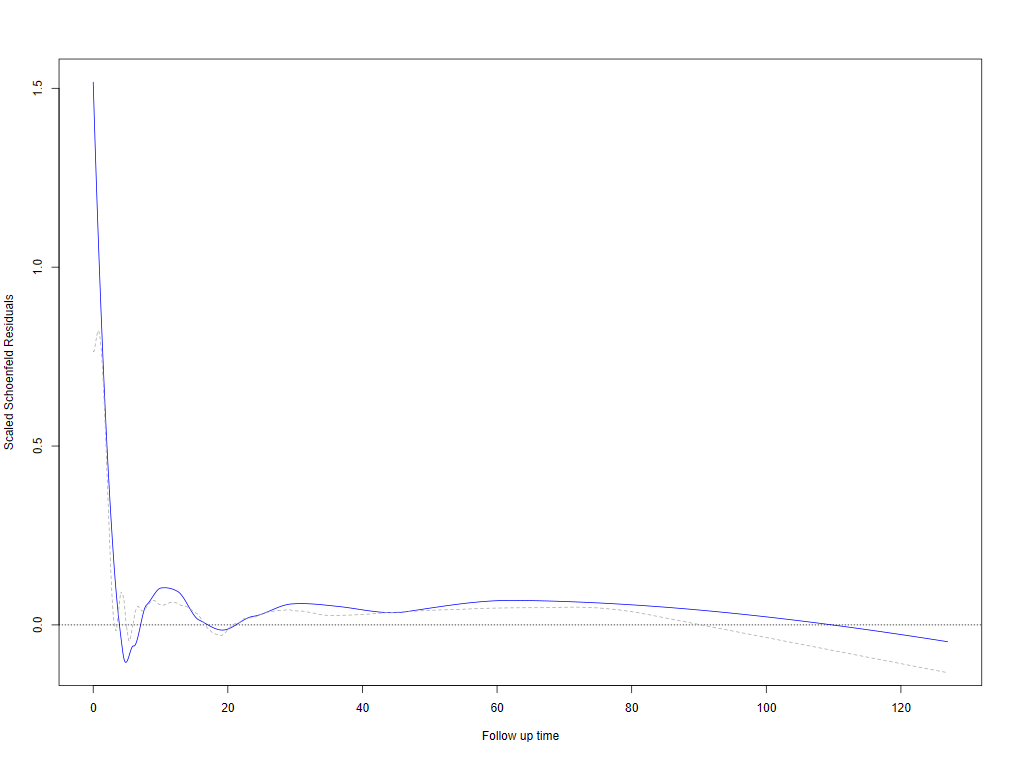

In [21]:
#| label: shap-criteria-nph4-plot-readm-additional-strata-resid-plot

res <- resid(coxph(formula_shap_readmit_clean, data = py_corrected_datasets[[1]]),
                "scaledsch")

time <- as.numeric(rownames(res))
y <- res[, "tr_outcome_adm_discharge_rule_violation_undet"]

z2 <- loess(y ~ time, span = 0.50)
ord <- order(time)

plot(time[ord], fitted(z2)[ord], type = "l", col = "blue",
     xlab = "Follow up time",
     ylab = "Scaled Schoenfeld Residuals")
abline(h = 0, lty = 3)

ss <- supsmu(time, y)
lines(ss$x, ss$y, lty = 2, col = "darkgray")


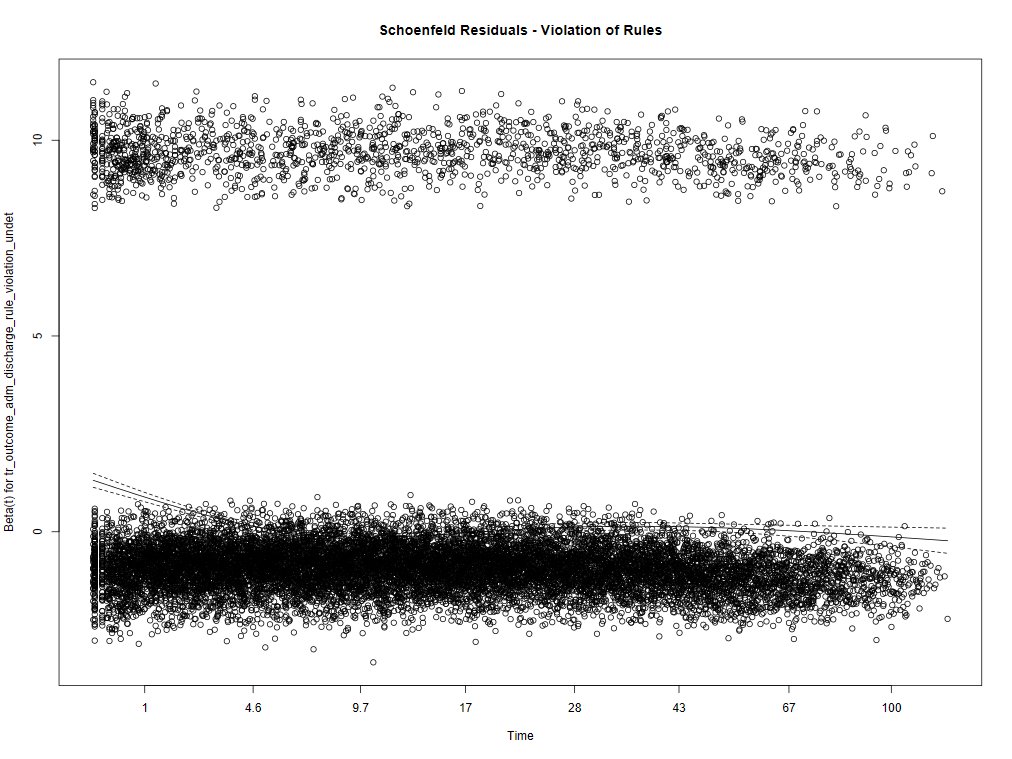

In [22]:
#| label: shap-criteria-nph5-plot-readm-additional-strata-resid-cox-zph

fit <- coxph(formula_shap_readmit_clean, data = py_corrected_datasets[[1]])
zph <- cox.zph(fit, transform = "km")  # or "rank", "identity"

# Plot with confidence bands
plot(zph, var = "tr_outcome_adm_discharge_rule_violation_undet", 
     main = "Schoenfeld Residuals - Violation of Rules")

In [23]:
#| label: print-function-mi-cv

#Function to print results in a nice format
source(paste0(project_root,"/cons/_alt_scripts/print_results_readmit_shap.R"))

#prs(results_readmit_shap)

print_results_readmit_shap.R loaded. Functions: print_pooled_results, view_pooled_results, prs


In [24]:
#| label: shap-criteria-nph6-plot-readm-additional-strata-resid-plot

formula_shap_readmit_clean_updated <- update(
  formula_shap_readmit_clean,
  . ~ . - tr_outcome_adm_discharge_rule_violation_undet + strat(tr_outcome_adm_discharge_rule_violation_undet)
)
formula_shap_readmit_clean_updated

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    adm_age_rec3 + porc_pobr + sex_rec_woman + ethnicity + dit_m + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    sub_dep_icd10_status_drug_dependence + occupation_condition_corr24_unemployed + 
    polysubstance_strict + primary_sub_mod_cocaine_powder + evaluacindelprocesoteraputico_logro_intermedio + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    primary_sub_mod_alcohol + strata(plan_type_strata) + strat(tr_outcome_adm_discharge_rule_violation_undet)

### Additional strata to readmission

In [25]:
#| label: shap-criteria-additional-strata2

gc()

results_readmit_shap2 <- evaluate_mi_cv_safe_strata(
  formula = as.formula(
  gsub(
    "strat\\(",
    "strata(",
    paste(deparse(formula_shap_readmit_clean_updated), collapse = " ")
  )
), 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6058 (repeat-quantile interval 0.6056-0.6061)
Pooled UnoC (survAUC::UnoC): 0.6784 (repeat-quantile interval 0.6473-0.6962)
Pooled IBS: 0.1602 (repeat-quantile interval 0.1601-0.1602)
Pooled IBS (IPCW-train): 0.3481 (repeat-quantile interval 0.3479-0.3483)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6294 (repeat-quantile interval 0.6291-0.6296, valid repeats=20)
  t=36 m: C=0.6135 (repeat-quantile interval 0.6133-0.6138, valid repeats=20)
  t=60 m: C=0.6087 (repeat-quantile interval 0.6085-0.6090, valid repeats=20)

Total runtime: 416.79 sec (6.95 min)


In [26]:
#| label: shap-criteria-additional-strata22

results_readmit_shap_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  tau = 99,                # Evaluate up to 60 months
  B = 500,
  cpus = cpus,
  verbose = TRUE,
  min_strata_events = 1
)

aicc_readmit_shap <- compute_mi_aicc(as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))), py_corrected_datasets)
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_shap$mean_aic - aicc_readmit_upd2$mean_aic))

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3479 (95% CI: 0.3357 - 0.3609)
Valid bootstrap replicates: 500 / 500


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272588.32
Mean AICc: 272588.38
Correction added (Penalty): 0.060690
Parameters (k): 21 | Effective Sample Size (Events): 15247


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.



Difference in Mean AIC: 39.23


In [27]:
compare_mi_models_d1(formula_shap_readmit_clean_updated,formula_shap_readmit_clean, py_corrected_datasets)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1 df2 dfcom     p.value           riv
 1 ~~ 2  47.39744   1   4 15225 0.002332909 0.00001724682


In [28]:
#| label: shap-criteria-additional-strata23

gc()
future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)
options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB

cal_readmit_shap2<- 
  calibrate_cph_grouped_corr(
    formula = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),  # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
  )
print(cal_readmit_shap2)


Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2

Warning messages:
1: In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.
2: In tfun(n - (nleft + 1L), 2L * id + 2L, power%/%2) :
  closing unused connection 10 (<-kubernetes.docker.internal:11653)
3: In tfun(n - (nleft + 1L), 2L * id + 2L, power%/%2) :
  closing unused connection 9 (<-kubernetes.docker.internal:11653)
4: In tfun(n - (nleft + 1L), 2L * id + 2L, power%/%2) :
  closing unused connection 8 (<-kubernetes.docker.internal:11653)
5: In tfun(n - (nleft + 1L), 2L * id + 2L, power%/%2) :
  closing unused connection 7 (<-kubernetes.docker.internal:11653)
6: In tfun(n - (nleft + 1L), 2L * id + 2L, power%/%2) :
  closing unused connection 6 (<-kubernetes.docker.internal:11653)
7: In tfun(n - (nleft + 1L), 2L * id + 2L, power%/%2) :
  closing unused connection 5 (<-kubernetes.docker.internal:11653)
8: In tfun(n - (nleft + 1L), 2L * id + 2L, power%/%2) :
  clo

<cph_grouped_calibration_corr>

$pooled_summary
 time_months ici_mean      ici_sd   ici_min  ici_p025  ici_p975   ici_max  e50_mean      e50_sd   e50_min  e50_p025  e50_p975   e50_max
          12       NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA
          36       NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA
          60 0.182719 0.001590543 0.1798654 0.1798654 0.1858899 0.1858899 0.1726064 0.001511856 0.1699099 0.1699099 0.1755397 0.1755397
          96       NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA
  e90_mean      e90_sd   e90_min  e90_p025  e90_p975   e90_max emax_mean     emax_sd  emax_min emax_p025 emax_p975  emax_max
        NA          NA        NA        NA        NA        NA        NA          NA        NA        NA        NA        NA
        NA          NA

In [29]:
#| label: shap-criteria2-additional-strata-run-ev-mi-cv-python-style

results_shap_add_strata_xgb_py <- evaluate_dual_cox_python_style(
  formula_readmit = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),  # Original formula with months variable,
  formula_death = formula_shap_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.


In [30]:
#| label: shap-criteria2-additional-strata-summ-python-style

results_shap_add_strata_xgb_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formula of readmission with additional strata")



Table: Global C-index and IBS summary, updated formula of readmission with additional strata

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519700| 0.0090251| 0.1371402| 0.1661768| 25|
|Readmission |IBS           |12     | 0.2026138| 0.0094830| 0.1855246| 0.2158807| 25|
|Readmission |IBS           |36     | 0.2940286| 0.0088744| 0.2747617| 0.3065304| 25|
|Readmission |IBS           |60     | 0.3311826| 0.0082261| 0.3136784| 0.3414768| 25|
|Readmission |IBS           |Global | 0.3584311| 0.0077723| 0.3430875| 0.3688206| 25|
|Readmission |Uno's C-Index |6      | 0.6412480| 0.0081244| 0.6296444| 0.6539760| 25|
|Readmission |Uno's C-Index |12     | 0.6295255| 0.0053438| 0.6198983| 0.6379025| 25|
|Readmission |Uno's C-Index |36     | 0.6135688| 0.0040008| 0.6067194| 0.6202294| 25|
|Readmission |Uno's C-Index |60     | 0.6088


With stratification, individuals in different strata have different baseline hazards, and therefore different predicted survival probabilities. This creates some discrimination purely from the stratum membership.

For the Wald test (𝐷1) to be valid, the ‘Reduced’ model must be a perfect subset of the ‘Full’ model. You cannot change the underlying structure (strata).


## Interactions



Interaction selection followed a two-stage screening procedure designed to balance discriminative power with replicability. Candidate interactions were initially identified from XGBoost SHAP-based pairwise analysis and subsequently filtered through joint clinical and stability criteria. Specifically, interactions were required to demonstrate both a minimum correlation magnitude with the outcome (∣ρ∣ ≥ 0.10) and a clinically meaningful effect size ( ∣SMD∣ ≥ 0.15), ensuring that retained terms were not merely statistically detectable but also prognostically relevant. To safeguard against overfitting to specific cross-validation folds or time horizons, we imposed stability constraints requiring that the interaction rank remain within an 8-position window across resampling iterations (rank_range ≤ 8) and that the correlation strength vary by no more than 0.05 (∣Δρ∣ ≤ 0.05). These replicability filters are conceptually distinct from proportional hazards assumptions; rather than enforcing time-invariant effects at the screening stage, we allowed the final Cox models to accommodate non-proportional hazards through stratification and restricted cubic splines. Additionally, interactions involving center-level plan-type indicators were excluded a priori to prevent norm violations, and dummy–dummy pairs originating from the same categorical variable were removed using a domain-knowledge family classifier to avoid collinear redundancy.

For interaction seleciton and specification source: Michael Lim & Trevor Hastie (2015) Learning Interactions via Hierarchical Group-Lasso Regularization, Journal of Computational and Graphical Statistics, 24:3, 627-654, DOI: 10.1080/10618600.2014.938812

In [31]:
#| label: shap-criteria-int-final

# 1. Load data
global_core <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"),
    "xgb11_dual_interactions_global_top_enriched"),
  show_col_types = FALSE
)

time_dep_u <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"), 
    "xgb11_dual_interactions_time_dependent"),
  show_col_types = FALSE
)

# 2. Family classifier (refined for eva_* subtypes)
get_family <- function(x) {
  dplyr::case_when(
    stringr::str_detect(x, "^plan_type_corr_")       ~ "plan_type",
    stringr::str_detect(x, "^adm_motive_")           ~ "adm_motive",
    stringr::str_detect(x, "^tr_outcome_")           ~ "tr_outcome",
    stringr::str_detect(x, "^primary_sub_mod_")      ~ "primary_sub_mod",
    stringr::str_detect(x, "^first_sub_used_")       ~ "first_sub_used",
    stringr::str_detect(x, "^marital_status_")       ~ "marital_status",
    stringr::str_detect(x, "^occupation_condition_") ~ "occupation_condition",
    stringr::str_detect(x, "^cohabitation_")         ~ "cohabitation",
    stringr::str_detect(x, "^tipo_de_vivienda_")     ~ "tipo_vivienda",
    stringr::str_detect(x, "^dx_")                   ~ "dx_psiq",
    stringr::str_detect(x, "^dg_psiq_")              ~ "dg_psiq",
    stringr::str_detect(x, "^eva_consumo")           ~ "eva_consumo",
    stringr::str_detect(x, "^eva_sm")                ~ "eva_sm",
    stringr::str_detect(x, "^eva_fam")               ~ "eva_fam",
    stringr::str_detect(x, "^eva_ocupacion")         ~ "eva_ocupacion",
    stringr::str_detect(x, "^eva_relinterp")         ~ "eva_relinterp",
    stringr::str_detect(x, "^eva_transgnorma")       ~ "eva_transgnorma",
    stringr::str_detect(x, "^sub_dep_icd10_")        ~ "sub_dep",
    stringr::str_detect(x, "^prim_sub_freq")         ~ "prim_sub_freq",
    stringr::str_detect(x, "^ed_attainment")         ~ "education",
    stringr::str_detect(x, "^tenure_status")         ~ "tenure",
    stringr::str_detect(x, "^sex_rec_")              ~ "sex",
    stringr::str_detect(x, "^adm_age")               ~ "age",
    stringr::str_detect(x, "^dit_m$")                ~ "dit_m",
    stringr::str_detect(x, "^ethnicity$")            ~ "ethnicity",
    stringr::str_detect(x, "^polysubstance")         ~ "polysubstance",
    stringr::str_detect(x, "^any_phys_dx$")          ~ "any_phys_dx",
    stringr::str_detect(x, "^evaluacindelproceso")   ~ "evaluacindelproceso",
    TRUE                                             ~ x
  )
}

# 3. Stability join (using your actual column names)
stable_core <- global_core %>%
  dplyr::left_join(
    time_dep_u %>%
      dplyr::select(
        outcome, main_feature, interactor,
        rank_range, abs_corr_delta, direction_flip_flag, time_dependent_flag
      ),
    by = c("outcome", "main_feature", "interactor")
  ) %>%
  dplyr::filter(
    #is.na(direction_flip_flag) | direction_flip_flag == FALSE,
    is.na(rank_range) | rank_range <= 8,
    is.na(abs_corr_delta) | abs_corr_delta <= 0.05,
    #is.na(time_dependent_flag) | time_dependent_flag == FALSE
  )

# 4. Effect-Size & Stability Rule + family exclusions
cox_discriminative_interactions <- stable_core %>%
  dplyr::mutate(
    fam_main = get_family(main_feature),
    fam_int  = get_family(interactor),
    score    = abs_corr * abs(smd_binarized)
  ) %>%
  dplyr::filter(
    abs_corr >= 0.10,
    !is.na(smd_binarized) & abs(smd_binarized) >= 0.15,
    fam_main != "plan_type",
    fam_int  != "plan_type",
    fam_main != fam_int
  ) %>%
  dplyr::select(
    outcome, main_feature, interactor, 
    abs_corr, smd_binarized, direction_q4_q1
  ) %>%
  dplyr::arrange(outcome, desc(abs_corr))

# 5. Results
cat("Candidates after family + stability filtering:", nrow(cox_discriminative_interactions), "\n")
knitr::kable(
  cox_discriminative_interactions,
  "markdown",
  caption = "Highly discriminative interactions for Cox models based on Effect-Size & Stability Rule"
)

Candidates after family + stability filtering: 13 




Table: Highly discriminative interactions for Cox models based on Effect-Size & Stability Rule

|outcome     |main_feature                           |interactor                    |  abs_corr| smd_binarized|direction_q4_q1 |
|:-----------|:--------------------------------------|:-----------------------------|---------:|-------------:|:---------------|
|Death       |any_phys_dx                            |primary_sub_mod_alcohol       | 0.1516792|    -0.3239456|Negative        |
|Death       |primary_sub_mod_alcohol                |adm_age_rec3                  | 0.1455185|    -0.2719126|Negative        |
|Death       |cohabitation_with_couple_children      |adm_age_rec3                  | 0.1273963|     0.2131233|Positive        |
|Death       |first_sub_used_alcohol                 |primary_sub_mod_alcohol       | 0.1188216|    -0.2526242|Negative        |
|Death       |primary_sub_mod_cocaine_paste          |polysubstance_strict          | 0.1151229|    -0.2614787|Negative        |

If variables were not available as a predictor, we added them as fixed effects. For `the first_sub_used_*` dummy family, we retained only `first_sub_used_alcohol `and its SHAP-selected interactions. Although a full family expansion was considered, the additional `first_sub_used_*` levels, particularly `first_sub_used_cocaine_powder`, produced sparse-cell instability/quasi-separation, with extreme coefficient estimates, very large standard errors, and infinite confidence intervals. Therefore, we used a SHAP-table-faithful specification instead of a full family expansion for this predictor family, while preserving hierarchy by retaining the main effect for `first_sub_used_alcohol`.

In [32]:
#| label: shap-criteria-int2-formula
# READMISSION
# READMISSION
# tr_outcome_* interaction excluded because tr_outcome family is already stratified.
# primary_sub_mod is re-referenced so primary_sub_mod_others can be modeled explicitly.

formula_shap_readmit_interact <- stats::update(
  formula_shap_readmit_clean_updated,
  . ~ . -
    primary_sub_mod_cocaine_paste +
    primary_sub_mod_others +
    sex_rec_woman:primary_sub_mod_cocaine_powder +
    sex_rec_woman:primary_sub_mod_alcohol +
    sex_rec_woman:primary_sub_mod_others
)


# DEATH
# Family-expanded interactions, with one reference level omitted per dummy family.
# evaluacindelprocesoteraputico_logro_minimo remains excluded because it was collinear.
# first_sub_used_* was not fully family-expanded.
# We retain only first_sub_used_alcohol because it was the SHAP-selected level.
# Full expansion caused sparse-cell instability/quasi-separation, especially for
# first_sub_used_cocaine_powder, with extreme coefficients, very large SEs, and
# infinite CIs. Hierarchy is preserved because first_sub_used_alcohol is included
# as a main effect in the base death formula.

formula_shap_death_interact <- stats::update(
  formula_death_updated2,
  . ~ . +
    primary_sub_mod_cocaine_powder +
    primary_sub_mod_alcohol +
    cohabitation_family_of_origin +
    cohabitation_with_couple_children +
    #first_sub_used_cocaine_paste +
    #first_sub_used_cocaine_powder +
    occupation_condition_corr24_inactive +
    polysubstance_strict +
    dit_m +
    evaluacindelprocesoteraputico_logro_intermedio +
    eva_sm_logro_intermedio +
    eva_sm_logro_minimo +
    any_phys_dx:(
      #primary_sub_mod_cocaine_paste +
      #primary_sub_mod_cocaine_powder +
      primary_sub_mod_alcohol
    ) +
    adm_age_rec3:(
      #primary_sub_mod_cocaine_paste +
      #primary_sub_mod_cocaine_powder +
      primary_sub_mod_alcohol
    ) +
    adm_age_rec3:(
      cohabitation_family_of_origin +
      cohabitation_with_couple_children
    ) +
    (
      first_sub_used_alcohol #+
      #first_sub_used_cocaine_paste +
      #first_sub_used_cocaine_powder
    ):(
      #primary_sub_mod_cocaine_paste +
      #primary_sub_mod_cocaine_powder +
      primary_sub_mod_alcohol
    ) +
    polysubstance_strict:(
      #primary_sub_mod_cocaine_paste +
      #primary_sub_mod_cocaine_powder +
      primary_sub_mod_alcohol
    ) +
    adm_age_rec3:(
      first_sub_used_alcohol #+
      #first_sub_used_cocaine_paste +
      #first_sub_used_cocaine_powder
    ) +
    polysubstance_strict:(
      first_sub_used_alcohol #+
      #first_sub_used_cocaine_paste +
      #first_sub_used_cocaine_powder
    ) +
    adm_age_rec3:(
      occupation_condition_corr24_unemployed +
      occupation_condition_corr24_inactive
    ) +
    any_phys_dx:(
      first_sub_used_alcohol #+
      #first_sub_used_cocaine_paste +
      #first_sub_used_cocaine_powder
    ) +
    dit_m:evaluacindelprocesoteraputico_logro_intermedio +
    dit_m:(
      eva_sm_logro_intermedio +
      eva_sm_logro_minimo
    )
)

# Convertir a fórmula
formula_shap_readmit_interact <- as.formula(gsub("strat\\(", "strata(", paste(deparse(formula_shap_readmit_interact), collapse = " ")))
formula_shap_death_interact <- as.formula(
  gsub("strat\\(", "strata(", 
       paste(deparse(formula_shap_death_interact), collapse = " "))
)

In [33]:
#| label: shap-criteria-int3-cox-zph-interactions

# Fit Cox model with the interaction formula
cox_shap_death_interact <- coxph(
  formula = formula_shap_death_interact,
  data = py_corrected_datasets[[1]],   # replace with your actual death dataset
  ties = "efron",
  x = TRUE
)

# Proportional hazards test
zph_shap_death_interact <- cox.zph(
  cox_shap_death_interact,
  transform = "km",
  terms = TRUE,
  global = TRUE
)

# Optional: table format
zph_death_interact_table <- as.data.frame(zph_shap_death_interact$table)
zph_death_interact_table$term <- rownames(zph_death_interact_table)

zph_death_interact_table <- zph_death_interact_table[, c("term", "chisq", "df", "p")]
zph_death_interact_table |> 
  dplyr::arrange(desc(chisq)) |>
  knitr::kable("markdown", caption = "Proportional Hazards Test for Cox Model with Interactions - Death Outcome")




Table: Proportional Hazards Test for Cox Model with Interactions - Death Outcome

|                                                          |term                                                      |       chisq| df|         p|
|:---------------------------------------------------------|:---------------------------------------------------------|-----------:|--:|---------:|
|GLOBAL                                                    |GLOBAL                                                    | 102.7082059| 77| 0.0268009|
|any_phys_dx:primary_sub_mod_alcohol                       |any_phys_dx:primary_sub_mod_alcohol                       |  12.6447760|  1| 0.0003766|
|any_phys_dx                                               |any_phys_dx                                               |  12.0254204|  1| 0.0005248|
|eva_fisica_logro_minimo                                   |eva_fisica_logro_minimo                                   |   9.7346100|  1| 0.0018083|
|adm_motive_justice_sector  

In [34]:
#| label: shap-criteria-int2-ev-mi-cv

results_readmit_int_shap <- evaluate_mi_cv_safe_strata(
    formula = formula_shap_readmit_interact, 
    imputed_list = py_corrected_datasets, 
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    k = 5,
    n_repeats = 20
)
results_death_int_shap <- evaluate_mi_cv_safe_strata(
    formula = formula_shap_death_interact, 
    imputed_list = py_corrected_datasets, 
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    k = 5,
    n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6030 (repeat-quantile interval 0.6026-0.6033)
Pooled UnoC (survAUC::UnoC): 0.6774 (repeat-quantile interval 0.6455-0.6972)
Pooled IBS: 0.1604 (repeat-quantile interval 0.1604-0.1605)
Pooled IBS (IPCW-train): 0.3492 (repeat-quantile interval 0.3490-0.3494)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6257 (repeat-quantile interval 0.6252-0.6260, valid repeats=20)
  t=36 m: C=0.6102 (repeat-quantile interval 0.6100-0.6105, valid repeats=20)
  t=60 m: C=0.6056 (repeat-quantile interval 0.6052-0.6060, valid repeats=20)

Total runtime: 410.68 sec (6.84 min)
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Tot

In [35]:
formula_shap_death_interact

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + porc_pobr + 
    dit_m + national_foreign + ethnicity + dg_psiq_cie_10_instudy + 
    dg_psiq_cie_10_dg + dx_f3_mood + dx_f6_personality + dx_f_any_severe_mental + 
    any_phys_dx + polysubstance_strict + sex_rec_woman + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    sub_dep_icd10_status_drug_dependence + any_violence_1_domestic_violence_sex_abuse + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    adm_motive_sanitary_sector + adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    adm_motive_justice_sector + adm_motive_other + first_sub_used_alcohol + 
    first_sub_used_cocaine_paste + first_sub_used_cocaine_powder + 
    first_sub_used_other + primary_sub_mod_cocaine_paste + primary_sub_mod_cocaine_powder + 
    primary_sub_mod_alcohol + primary_sub_mod_others + tipo_de_vivienda_rec2_other_unknown + 
    occupation_condi

In [36]:
#| label: shap-criteria-int2-oob-ibs

results_readmit_shap_int_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_readmit_interact,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_int_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_death_interact,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
# ====
aicc_readmit_shap_int <- compute_mi_aicc(formula_shap_readmit_interact, py_corrected_datasets)
aicc_readmit_shap_int
aicc_death_shap_int <- compute_mi_aicc(formula_shap_death_interact, py_corrected_datasets)
aicc_death_shap_int

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3490 (95% CI: 0.3367 - 0.3619)
Valid bootstrap replicates: 500 / 500


Warning messages:
1: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  23 ; coefficient may be infinite. 
2: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  23 ; coefficient may be infinite. 
3: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  23 ; coefficient may be infinite. 
4: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  23 ; coefficient may be infinite. 
5: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  23 ; coefficient may be infinite. 


Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0881 (95% CI: 0.0817 - 0.0953)
Valid bootstrap replicates: 500 / 500


There were 50 or more warnings (use warnings() to see the first 50)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272712.30
Mean AICc: 272712.38
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51472.64
Mean AICc: 51476.70
Correction added (Penalty): 4.056738
Parameters (k): 77 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51476.7

$full_results
       aic correction     aicc  k n_events
1 51463.77   4.056738 51467.83 77     3039
2 51475.62   4.056738 51479.67 77     3039
3 51474.74   4.056738 51478.79 77     3039
4 51473.18   4.056738 51477.23 77     3039
5 51475.90   4.056738 51479.95 77     3039


In [37]:
compare_mi_models_d1(formula_shap_readmit_interact, formula_shap_readmit_clean_updated, py_corrected_datasets)
compare_mi_models_d1(formula_shap_death_interact, formula_shap_death, py_corrected_datasets)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value           riv
 1 ~~ 2  9.873995   4 15220.98 15223 5.630791e-08 0.00002944986
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value        riv
 1 ~~ 2  6.902722  65 2892.232  2962 1.148519e-53 0.04665564


In [38]:
#| label: shap-criteria-int2-cal

cal_readmit_shap_int<- 
    calibrate_cph_grouped_corr(
    formula = formula_shap_readmit_interact,
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
  )
print(cal_readmit_shap_int)

cal_death_shap_int<- 
    calibrate_cph_grouped_corr(
    formula = formula_shap_death_interact,
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
  )
print(cal_death_shap_int)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2

In [39]:
#| label: shap-interaction-dual-python-style

results_shap_xgb_py_upd_int <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = formula_shap_death_interact,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [40]:
#| label: shap-criteria-int2-dual-cox-python-style

results_shap_xgb_py_upd_int$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions")



Table: Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1520687| 0.0090467| 0.1371715| 0.1662754| 25|
|Readmission |IBS           |12     | 0.2028592| 0.0095415| 0.1856327| 0.2160535| 25|
|Readmission |IBS           |36     | 0.2946955| 0.0089542| 0.2752371| 0.3074727| 25|
|Readmission |IBS           |60     | 0.3320863| 0.0083104| 0.3144044| 0.3425532| 25|
|Readmission |IBS           |Global | 0.3596460| 0.0078672| 0.3441409| 0.3699307| 25|
|Readmission |Uno's C-Index |6      | 0.6390553| 0.0080266| 0.6284433| 0.6524479| 25|
|Readmission |Uno's C-Index |12     | 0.6257608| 0.0055361| 0.6145245| 0.6334244| 25|
|Readmission |Uno's C-Index |36     | 0.6101546| 0.0040629| 0.6021769| 0.6174307| 25|
|Readmission |Uno's C-Index |

Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


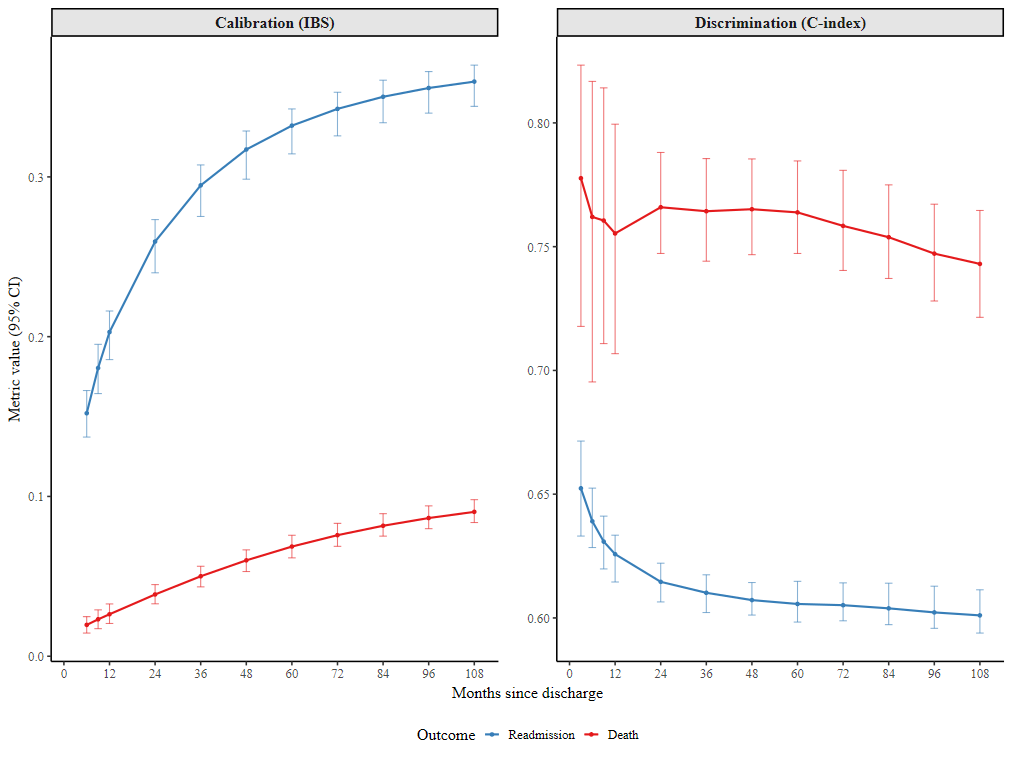

In [41]:
#| label: shap-criteria-int3-dual-cox-python-style-plot-by-time

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_xgb_py_upd_int$summary %>%
  dplyr::filter(Time != "Global") %>%
  dplyr::mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% dplyr::filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% dplyr::filter(Metric == "IBS")

p_faceted_upd_int <- time_metrics %>%
  dplyr::mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted_upd_int



## Functional forms



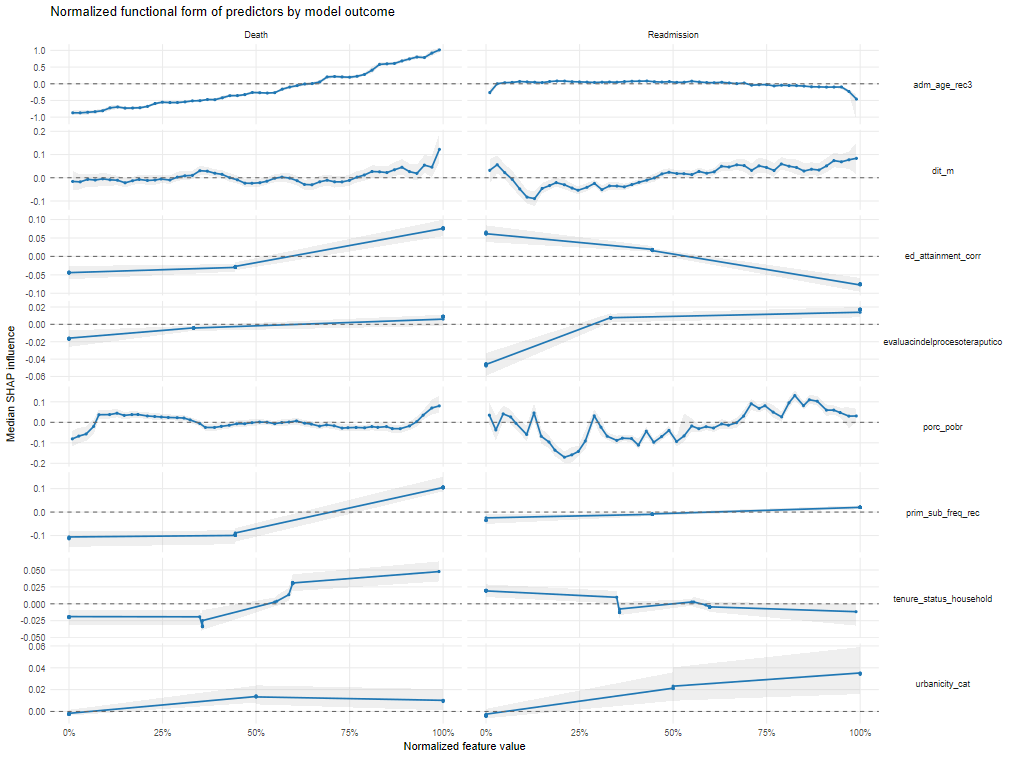

In [42]:
#| label: shap-criteria-func-form-get-shap-values

global_xgb_func_form <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"),
    "XGB12_corr_Functional_Forms_Dual_Aggregated"),
  show_col_types = FALSE
)
shap_norm <- global_xgb_func_form %>%
  filter(
    is.finite(Feature_Value),
    is.finite(SHAP_Impact)
  ) %>%
  group_by(Predictor) %>%
  mutate(
    n_unique = n_distinct(Feature_Value),
    Feature_Value_norm = dplyr::case_when(
      n_unique <= 1 ~ 0.5,
      n_unique <= 10 ~ (dense_rank(Feature_Value) - 1) / (n_unique - 1),
      TRUE ~ percent_rank(Feature_Value)
    )
  ) %>%
  ungroup()
shap_curve_norm <- shap_norm %>%
  group_by(Outcome, Predictor) %>%
  mutate(value_bin = ntile(Feature_Value_norm, 50)) %>%
  group_by(Outcome, Predictor, value_bin) %>%
  summarise(
    x_norm = median(Feature_Value_norm, na.rm = TRUE),
    x_raw_median = median(Feature_Value, na.rm = TRUE),
    shap_median = median(SHAP_Impact, na.rm = TRUE),
    shap_q25 = quantile(SHAP_Impact, 0.25, na.rm = TRUE),
    shap_q75 = quantile(SHAP_Impact, 0.75, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(filter(shap_curve_norm, !grepl("eva_",Predictor)), aes(x = x_norm, y = shap_median)) +
  geom_ribbon(aes(ymin = shap_q25, ymax = shap_q75), alpha = 0.2, fill = "grey70") +
  geom_line(linewidth = 0.8, colour = "#1f77b4") +
  geom_point(size = 0.8, colour = "#1f77b4") +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  facet_grid(Predictor ~ Outcome, scales = "free_y") +
  scale_x_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  labs(
    x = "Normalized feature value",
    y = "Median SHAP influence",
    title = "Normalized functional form of predictors by model outcome"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.y = element_text(angle = 0),
    panel.grid.minor = element_blank()
  )

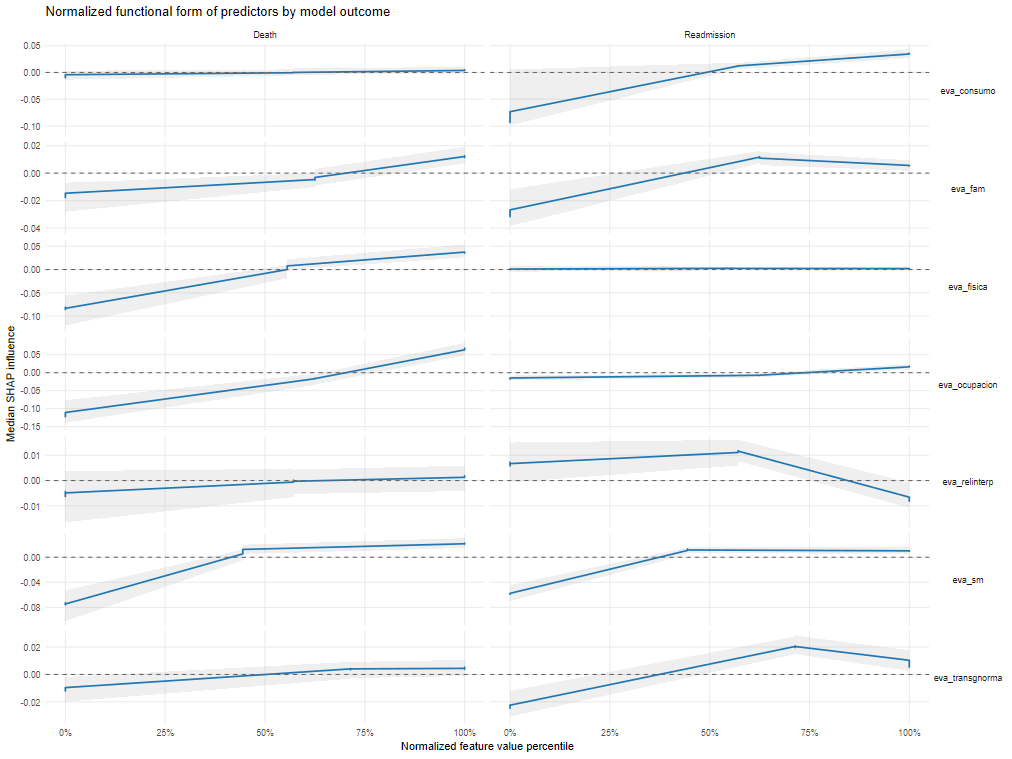

In [43]:
#| label: shap-criteria-func-form-get-shap-values2

ggplot(filter(shap_curve_norm, grepl("eva_",Predictor)), aes(x = x_norm, y = shap_median)) +
  geom_ribbon(
    aes(ymin = shap_q25, ymax = shap_q75),
    alpha = 0.2,
    fill = "grey70"
  ) +
  geom_line(linewidth = 0.8, colour = "#1f77b4") +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  facet_grid(Predictor ~ Outcome, scales = "free_y") +
  scale_x_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  labs(
    x = "Normalized feature value percentile",
    y = "Median SHAP influence",
    title = "Normalized functional form of predictors by model outcome"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.y = element_text(angle = 0),
    panel.grid.minor = element_blank()
  )

For readmission model, very short treatment durations (e.g., 0.47 days) have a positive SHAP value (increasing readmission risk). The risk drops to negative values for medium durations (e.g., 2.38 to 3.87 days), and then rises steeply back to positive values for longer durations (e.g., >11 days).

For poverty percentage, theres a threshold / step-function, where lower poverty percentages (8%-9%) are associated with strong negative SHAP values (~ -0.11 to -14). However, once the percentage crosses a threshold (around 13% to 18%) the SHAP impact sharply jumps to strong positive values (~ 0.14).

For admission age, we observe an exponential acceleration (for Death) vs. inverted U-shape (for Readmission). Mortality risk typically follows the Gompertz law (exponential increase with age). Readmission is highly dependent on behavioral factors more prevalent in younger cohorts in this specific dataset.

For evaluation of the therapeutic process, the SHAP values bounce non-linearly across the integer codes. The suggested transformation is one-hot encoding.

In [44]:
#| label: shap-criteria-func-form-linear-terms-and-scores

# helper: create 3-level score for interaction terms based on main effect and interactor presence
make_3level_score <- function(intermedio, minimo) {
  dplyr::case_when(
    minimo == 1 ~ 2,
    intermedio == 1 ~ 1,
    TRUE ~ 0
  )
}
add_boot_linear_terms <- function(df) {
df <- df %>%
  dplyr::mutate(
    # Constructing linear scores (0 = Ref, 1 = Intermedio, 2 = Minimo) # Categorical variables for readmission
    eva_consumo_score   = eva_consumo_logro_intermedio * 1 + eva_consumo_logro_minimo * 2,
    eva_ocupacion_score = eva_ocupacion_logro_intermedio * 1 + eva_ocupacion_logro_minimo * 2,
    eva_fisica_score    = eva_fisica_logro_intermedio * 1 + eva_fisica_logro_minimo * 2,
    eva_relinterp_score = eva_relinterp_logro_intermedio * 1 + eva_relinterp_logro_minimo * 2,
    # Linear score for Death only, remains dummy for Readmission
    eva_sm_score        = eva_sm_logro_intermedio * 1 + eva_sm_logro_minimo * 2,
    # Constructing others (0 = Ref, 1 = Level 2, 2 = Level 3) # Categorical variables for readmission
    ed_attainment_score = ed_attainment_corr_2_completed_high_school_or_less * 1 + 
                          ed_attainment_corr_3_completed_primary_school_or_less * 2,
    # Categorical variables for readmission                        
    prim_sub_freq_score = prim_sub_freq_rec_2_2_6_days_wk * 1 + prim_sub_freq_rec_3_daily * 2
  )
}
py_corrected_datasets_boot <- lapply(py_corrected_datasets, add_boot_linear_terms)

In [45]:
formula_shap_readmit_interact

Surv(readmit_time_from_disch_m, readmit_event) ~ adm_age_rec3 + 
    porc_pobr + sex_rec_woman + ethnicity + dit_m + eva_consumo_logro_intermedio + 
    eva_consumo_logro_minimo + ed_attainment_corr_2_completed_high_school_or_less + 
    ed_attainment_corr_3_completed_primary_school_or_less + sub_dep_icd10_status_drug_dependence + 
    occupation_condition_corr24_unemployed + polysubstance_strict + 
    primary_sub_mod_cocaine_powder + evaluacindelprocesoteraputico_logro_intermedio + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    primary_sub_mod_alcohol + strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet) + 
    primary_sub_mod_others + sex_rec_woman:primary_sub_mod_cocaine_powder + 
    sex_rec_woman:primary_sub_mod_alcohol + sex_rec_woman:primary_sub_mod_others

In [46]:
#| label: shap-criteria-func-form-rcs

# ============================================================
# Functional-form sensitivity models based on actual predictors
# ============================================================

# Requirements:
# 1. Create dit_m_cap36 before fitting readmission models.
# 2. Use fixed knots across imputations/folds, preferably estimated
#    from the development/training data only.
# 3. Do not add variables to the death model that are not already in
#    formula_shap_death_interact unless this is an intentional
#    predictor-set expansion.

add_nonlinear_transf <- function(df) {
  # Capar dit_m en 36
  df <- df %>%
    dplyr::mutate(
      dit_m_cap36 = pmin(dit_m, 36, na.rm = TRUE),
      # Transformaciones spline usando knots fijos
      dit_m_ns1 = splines::ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,1],
      dit_m_ns2 = splines::ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,2],
      dit_m_ns3 = splines::ns(dit_m, knots = c(1.1, 3.9, 7.9, 19.3))[,3],
      #
      porc_pobr_ns1 = splines::ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,1],
      porc_pobr_ns2 = splines::ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,2],
      porc_pobr_ns3 = splines::ns(porc_pobr, knots = c(0.053, 0.105, 0.146, 0.261))[,3],  
      age_ns1 = splines::ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,1],
      age_ns2 = splines::ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,2],
      age_ns3 = splines::ns(adm_age_rec3,
                   knots = quantile(df$adm_age_rec3,
                                    probs = c(0.05, 0.35, 0.65, 0.95),
                                    na.rm = TRUE))[,3]
    )
  return(df)
}  # If you do not want to calculate them manually, use rcs(age, 4).

py_corrected_datasets_boot <- lapply(py_corrected_datasets_boot, add_nonlinear_transf)

In [47]:
#| label: shap-criteria-func-form-precomputed-ns-readm

# ============================================================
# READMISSION: baseline linear model
# ============================================================
form_readmit_xgb_linear <- formula_shap_readmit_interact

# ============================================================
# READMISSION: age natural spline
# ============================================================
form_readmit_xgb_age_ns3 <- update(
  formula_shap_readmit_interact,
  . ~ .
    - adm_age_rec3
    + age_ns1 + age_ns2 + age_ns3
)

# ============================================================
# READMISSION: dit_m capped natural spline
# ============================================================
# Replaces raw dit_m with the precomputed spline basis based on dit_m_cap36.
form_readmit_xgb_dit_ns3 <- update(
  formula_shap_readmit_interact,
  . ~ .
    - dit_m
    + dit_m_ns1 + dit_m_ns2 + dit_m_ns3
)

form_readmit_xgb_dit_hinge5 <- update(
  formula_shap_readmit_interact,
  . ~ . - dit_m + dit_m_hinge5
)
# Optional sensitivity: quadratic capped dit_m
form_readmit_xgb_dit_quad_sens <- update(
  formula_shap_readmit_interact,
  . ~ .
    - dit_m
    + dit_m_cap36 + I(dit_m_cap36^2)
)
# Optional sensitivity: log capped dit_m
form_readmit_xgb_dit_log_sens <- update(
  formula_shap_readmit_interact,
  . ~ .
    - dit_m
    + log1p(dit_m_cap36)
)

# ============================================================
# READMISSION: poverty natural spline
# ============================================================
form_readmit_xgb_pobr_ns3 <- update(
  formula_shap_readmit_interact,
  . ~ .
    - porc_pobr
    + porc_pobr_ns1 + porc_pobr_ns2 + porc_pobr_ns3
)

form_readmit_xgb_porc_pobr_hinge015 <- update(
  formula_shap_readmit_interact,
  . ~ .
    - porc_pobr
    + porc_pobr_hinge015
)

form_readmit_xgb_eva_sm_any <- update(
  formula_shap_readmit_interact,
  . ~ . -
    eva_sm_logro_intermedio -
    eva_sm_logro_minimo +
    eva_sm_any
)

form_readmit_xgb_eva_consumo_any <- update(
  formula_shap_readmit_interact,
  . ~ . -
    eva_consumo_logro_intermedio -
    eva_consumo_logro_minimo +
    eva_consumo_any
)

In [48]:
#formula_shap_death_interact
formula_death_updated2

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + porc_pobr + 
    dit_m + national_foreign + ethnicity + dg_psiq_cie_10_instudy + 
    dg_psiq_cie_10_dg + dx_f3_mood + dx_f6_personality + dx_f_any_severe_mental + 
    any_phys_dx + polysubstance_strict + sex_rec_woman + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    sub_dep_icd10_status_drug_dependence + any_violence_1_domestic_violence_sex_abuse + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    adm_motive_sanitary_sector + adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    adm_motive_justice_sector + adm_motive_other + first_sub_used_alcohol + 
    first_sub_used_cocaine_paste + first_sub_used_cocaine_powder + 
    first_sub_used_other + primary_sub_mod_cocaine_paste + primary_sub_mod_cocaine_powder + 
    primary_sub_mod_alcohol + primary_sub_mod_others + tipo_de_vivienda_rec2_other_unknown + 
    occupation_condi

In [49]:
#| label: shap-criteria-func-form-death-nonlinear-transformations

add_nonlinear_transf2 <- function(df) {
  df <- df %>%
    dplyr::mutate(
      # Continuous variables available as-is
      dit_m_cap36 = dplyr::if_else(
        is.na(dit_m),
        NA_real_,
        pmin(dit_m, 36)
      ),

      dit_m_hinge9 = dplyr::if_else(
        is.na(dit_m_cap36),
        NA_real_,
        pmax(0, dit_m_cap36 - 9)
      ),

      dit_m_hinge5 = dplyr::if_else(
        is.na(dit_m_cap36),
        NA_real_,
        pmax(0, dit_m_cap36 - 5)
      ),

      porc_pobr_hinge022 = dplyr::if_else(
        is.na(porc_pobr),
        NA_real_,
        pmax(0, porc_pobr - 0.22)
      ),

      porc_pobr_hinge015 = dplyr::if_else(
        is.na(porc_pobr),
        NA_real_,
        pmax(0, porc_pobr - 0.15)
      ),      

      adm_age_rec3_c = adm_age_rec3 - mean(adm_age_rec3, na.rm = TRUE),

      # From dummy variables already in the model
      prim_sub_freq_high = prim_sub_freq_rec_3_daily,

      eva_fisica_any = dplyr::if_else(
        is.na(eva_fisica_logro_intermedio) & is.na(eva_fisica_logro_minimo),
        NA_integer_,
        as.integer(
          dplyr::coalesce(eva_fisica_logro_intermedio, 0) == 1 |
            dplyr::coalesce(eva_fisica_logro_minimo, 0) == 1
        )
      ),

      eva_sm_any = dplyr::if_else(
        is.na(eva_sm_logro_intermedio) & is.na(eva_sm_logro_minimo),
        NA_integer_,
        as.integer(
          dplyr::coalesce(eva_sm_logro_intermedio, 0) == 1 |
            dplyr::coalesce(eva_sm_logro_minimo, 0) == 1
        )
      ),

      eva_consumo_any = dplyr::if_else(
        is.na(eva_consumo_logro_intermedio) & is.na(eva_consumo_logro_minimo),
        NA_integer_,
        as.integer(
          dplyr::coalesce(eva_consumo_logro_intermedio, 0) == 1 |
            dplyr::coalesce(eva_consumo_logro_minimo, 0) == 1
        )
      ),

      ed_attainment_high = ed_attainment_corr_3_completed_primary_school_or_less,

      tenure_hinge1 = pmax(
        0,
        dplyr::coalesce(tenure_status_household_others, 0) * 1 +
          dplyr::coalesce(tenure_status_household_renting, 0) * 2 +
          dplyr::coalesce(tenure_status_household_stays_temporarily_with_a_relative, 0) * 3 +
          dplyr::coalesce(tenure_status_household_illegal_settlement, 0) * 4 -
          1
      )
    )

  return(df)
}

py_corrected_datasets_boot <- lapply(py_corrected_datasets_boot, add_nonlinear_transf2)


In [50]:
#| label: shap-criteria-func-form-precomputed-ns-death

# # ============================================================
# # DEATH: baseline linear model
# # ============================================================
# form_death_xgb_linear <- formula_death_updated2

# # ============================================================
# # DEATH: preferred model
# # ============================================================
# # Keep linear age as preferred unless the spline sensitivity clearly improves
# # AICc/IBS without hurting discrimination.
# form_death_xgb_preferred <- formula_death_updated2

# # ============================================================
# # DEATH: age natural spline sensitivity
# # ============================================================
# form_death_xgb_age_ns3_sens <- update(
#   formula_death_updated2,
#   . ~ .
#     - adm_age_rec3
#     # - adm_age_rec3:primary_sub_mod_alcohol
#     # - adm_age_rec3:cohabitation_family_of_origin
#     # - adm_age_rec3:cohabitation_with_couple_children
#     # - adm_age_rec3:first_sub_used_alcohol
#     # - adm_age_rec3:occupation_condition_corr24_unemployed
#     # - adm_age_rec3:occupation_condition_corr24_inactive

#     + age_ns1 + age_ns2 + age_ns3

#     # + age_ns1:primary_sub_mod_alcohol
#     # + age_ns2:primary_sub_mod_alcohol
#     # + age_ns3:primary_sub_mod_alcohol

#     # + age_ns1:cohabitation_family_of_origin
#     # + age_ns2:cohabitation_family_of_origin
#     # + age_ns3:cohabitation_family_of_origin

#     # + age_ns1:cohabitation_with_couple_children
#     # + age_ns2:cohabitation_with_couple_children
#     # + age_ns3:cohabitation_with_couple_children

#     # + age_ns1:first_sub_used_alcohol
#     # + age_ns2:first_sub_used_alcohol
#     # + age_ns3:first_sub_used_alcohol

#     # + age_ns1:occupation_condition_corr24_unemployed
#     # + age_ns2:occupation_condition_corr24_unemployed
#     # + age_ns3:occupation_condition_corr24_unemployed

#     # + age_ns1:occupation_condition_corr24_inactive
#     # + age_ns2:occupation_condition_corr24_inactive
#     # + age_ns3:occupation_condition_corr24_inactive
# )

# # Optional simpler sensitivity: quadratic age
# form_death_xgb_age_quad_sens <- update(
#   formula_death_updated2,
#   . ~ .
#     # - adm_age_rec3
#     # - adm_age_rec3:primary_sub_mod_alcohol
#     # - adm_age_rec3:cohabitation_family_of_origin
#     # - adm_age_rec3:cohabitation_with_couple_children
#     # - adm_age_rec3:first_sub_used_alcohol
#     # - adm_age_rec3:occupation_condition_corr24_unemployed
#     # - adm_age_rec3:occupation_condition_corr24_inactive

#     + adm_age_rec3 + I(adm_age_rec3^2)

#     # + adm_age_rec3:primary_sub_mod_alcohol
#     # + I(adm_age_rec3^2):primary_sub_mod_alcohol

#     # + adm_age_rec3:cohabitation_family_of_origin
#     # + I(adm_age_rec3^2):cohabitation_family_of_origin

#     # + adm_age_rec3:cohabitation_with_couple_children
#     # + I(adm_age_rec3^2):cohabitation_with_couple_children

#     # + adm_age_rec3:first_sub_used_alcohol
#     # + I(adm_age_rec3^2):first_sub_used_alcohol

#     # + adm_age_rec3:occupation_condition_corr24_unemployed
#     # + I(adm_age_rec3^2):occupation_condition_corr24_unemployed

#     # + adm_age_rec3:occupation_condition_corr24_inactive
#     # + I(adm_age_rec3^2):occupation_condition_corr24_inactive
# )

In [51]:
#| label: shap-criteria-func-form-nonlin-formula-death

# 1) Replace dit_m with dit_m tail hinge only
form_death_xgb_dit_hinge9 <- update(
  formula_death_updated2,
  . ~ . - dit_m + dit_m_hinge9
)

# 2) Replace porc_pobr with poverty tail hinge only
form_death_xgb_pobr_hinge022 <- update(
  formula_death_updated2,
  . ~ . - porc_pobr + porc_pobr_hinge022
)

# 3) Replace tenure dummies with tenure hinge only
form_death_xgb_tenure_hinge1 <- update(
  formula_death_updated2,
  . ~ . -
    tenure_status_household_renting -
    tenure_status_household_others -
    tenure_status_household_stays_temporarily_with_a_relative -
    tenure_status_household_illegal_settlement +
    tenure_hinge1
)

# 4) Replace primary substance frequency dummies with high indicator only
form_death_xgb_prim_sub_freq_high <- update(
  formula_death_updated2,
  . ~ . -
    prim_sub_freq_rec_2_2_6_days_wk -
    prim_sub_freq_rec_3_daily +
    prim_sub_freq_high
)

# 5) Replace physical evaluation dummies with any-problem indicator only
form_death_xgb_eva_fisica_any <- update(
  formula_death_updated2,
  . ~ . -
    eva_fisica_logro_intermedio -
    eva_fisica_logro_minimo +
    eva_fisica_any
)

# 6) Replace mental health evaluation dummies with any-problem indicator only
form_death_xgb_eva_sm_any <- update(
  formula_death_updated2,
  . ~ . -
    eva_sm_logro_intermedio -
    eva_sm_logro_minimo +
    eva_sm_any
)

# 7) Replace education dummies with high-risk education indicator only
form_death_xgb_ed_attainment_high <- update(
  formula_death_updated2,
  . ~ . -
    ed_attainment_corr_2_completed_high_school_or_less -
    ed_attainment_corr_3_completed_primary_school_or_less +
    ed_attainment_high
)

form_death_xgb_eva_consumo_any <- update(
  formula_death_updated2,
  . ~ . -
    eva_consumo_logro_intermedio -
    eva_consumo_logro_minimo +
    eva_consumo_any
)


In [52]:
#| label: shap-post-interaction-dual-python-style

results_shap_xgb_py_upd_post_int <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [53]:
#| label: shap-criteria-post-int2-dual-cox-python-style

results_shap_xgb_py_upd_post_int$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions for readmission, but not for death")



Table: Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions for readmission, but not for death

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1520687| 0.0090467| 0.1371715| 0.1662754| 25|
|Readmission |IBS           |12     | 0.2028592| 0.0095415| 0.1856327| 0.2160535| 25|
|Readmission |IBS           |36     | 0.2946955| 0.0089542| 0.2752371| 0.3074727| 25|
|Readmission |IBS           |60     | 0.3320863| 0.0083104| 0.3144044| 0.3425532| 25|
|Readmission |IBS           |Global | 0.3596460| 0.0078672| 0.3441409| 0.3699307| 25|
|Readmission |Uno's C-Index |6      | 0.6390553| 0.0080266| 0.6284433| 0.6524479| 25|
|Readmission |Uno's C-Index |12     | 0.6257608| 0.0055361| 0.6145245| 0.6334244| 25|
|Readmission |Uno's C-Index |36     | 0.6101546| 0.0040629| 0.6021769| 0.6174307

### Admission age

In [54]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readmit-test

cat("\nComparing linear age terms vs. polynomial and spline age terms for readmission:\n")
compute_mi_aicc(formula_shap_readmit_interact  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_age_ns3  , py_corrected_datasets_boot)


Comparing linear age terms vs. polynomial and spline age terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272712.30
Mean AICc: 272712.38
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272681.54
Mean AICc: 272681.63
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272681.6

$full_results
       aic correction     aicc  k n_events
1 272682.5 0.09224704 272682.6 26    15247
2 272680.4 0.09224704 272680.5 26    15247
3 272682.2 0.09224704 272682.3 26    15247
4 272680.9 0.09224704 272681.0 26    15247
5 272681.7 0.09224704 272681.8 26    15247


In [55]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readm-test

gc()

results_shap_py_int_readm_age_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_age_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Age spline df=3", results_shap_py_int_readm_age_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model with spline age terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3596460| 0.0078672| 0.3441409| 0.3699307| 25|
|Age spline df=3 |Readmission |IBS           |Global | 0.3900303| 0.0083140| 0.3750219| 0.4025832| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6002127| 0.0055611| 0.5921529| 0.6099795| 25|
|Age spline df=3 |Readmission |Uno's C-Index |Global | 0.6007432| 0.0052265| 0.5937393| 0.6103333| 25|

### Treatment duration

In [56]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-tr-duration

cat("\nComparing linear age terms vs. polynomial and spline age terms for readmission:\n")
compute_mi_aicc(formula_shap_readmit_interact  , py_corrected_datasets)
compute_mi_aicc(form_readmit_xgb_dit_ns3  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_dit_hinge5  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_dit_quad_sens  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_dit_log_sens  , py_corrected_datasets_boot)


Comparing linear age terms vs. polynomial and spline age terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272712.30
Mean AICc: 272712.38
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272692.13
Mean AICc: 272692.23
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272720.62
Mean AICc: 272720.70
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272691.74
Mean AICc: 272691.83
Correction added (Penalty): 0.085408
Parameters (k): 25 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272693.15
Mean AICc: 272693.23
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272693.2

$full_results
       aic correction     aicc  k n_events
1 272694.1 0.07883327 272694.2 24    15247
2 272691.9 0.07883327 272692.0 24    15247
3 272693.9 0.07883327 272693.9 24    15247
4 272692.4 0.07883327 272692.5 24    15247
5 272693.4 0.07883327 272693.5 24    15247


In [57]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-tr-duration-test

gc()

results_shap_py_int_readm_dit_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)
results_shap_py_int_readm_dit_quad <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_quad_sens,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)
results_shap_py_int_readm_dit_hinge5 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_hinge5,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)
results_shap_py_int_readm_dit_log <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_log_sens,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "DIT spline df=3", results_shap_py_int_readm_dit_ns3$summary),
  cbind.data.frame(model= "DIT cuadratic", results_shap_py_int_readm_dit_quad$summary),
  cbind.data.frame(model= "DIT hinge at 5", results_shap_py_int_readm_dit_hinge5$summary),
  cbind.data.frame(model= "DIT logarithmic", results_shap_py_int_readm_dit_log$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with different tr.duration terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model with different tr.duration terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3596460| 0.0078672| 0.3441409| 0.3699307| 25|
|DIT spline df=3 |Readmission |IBS           |Global | 0.3901930| 0.0084129| 0.3745468| 0.4029909| 25|
|DIT cuadratic   |Readmission |IBS           |Global | 0.3900887| 0.0083698| 0.3745294| 0.4028659| 25|
|DIT hinge at 5  |Readmission |IBS           |Global | 0.3904239| 0.0083400| 0.3751459| 0.4031705| 25|
|DIT logarithmic |Readmission |IBS           |Global | 0.3899353| 0.0083237| 0.3745634| 0.4026206| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6002127| 0.0055611| 0.5921529| 0.6099795| 25|
|DIT spline df=3 |Readmission |Uno's C-Index |Global | 0.6007141| 0.0053607| 0.5925

#### Death

In [58]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-death-tr-duration

cat("\nComparing linear duration vs. tail-hinge at value=9 for death:\n")
compute_mi_aicc(formula_death_updated2  , py_corrected_datasets_boot)
compute_mi_aicc( form_death_xgb_dit_hinge9 , py_corrected_datasets_boot)


Comparing linear duration vs. tail-hinge at value=9 for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51495.94
Mean AICc: 51498.65
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51498.65

$full_results
       aic correction     aicc  k n_events
1 51489.08   2.710588 51491.79 63     3039
2 51500.65   2.710588 51503.36 63     3039
3 51497.87   2.710588 51500.58 63     3039
4 51496.51   2.710588 51499.22 63     3039
5 51495.59   2.710588 51498.30 63     3039


In [59]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-death-dit-test

gc()

results_shap_py_int_death_dit_hinge_9 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = form_death_xgb_dit_hinge9,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "DIT hinge at 9", results_shap_py_int_death_dit_hinge_9$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model with different tr.duration terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model with different tr.duration terms

|model          |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear         |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|DIT hinge at 9 |Death |IBS           |Global | 0.1136859| 0.0048894| 0.1056536| 0.1220078| 25|
|Linear         |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|DIT hinge at 9 |Death |Uno's C-Index |Global | 0.7423248| 0.0107263| 0.7236747| 0.7604908| 25|

### Poverty index

In [60]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-poverty

cat("\nComparing linear proverty index terms vs. spline & nonlinear transformation of poverty index terms for readmission:\n")
compute_mi_aicc(formula_shap_readmit_interact  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_pobr_ns3  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_porc_pobr_hinge015  , py_corrected_datasets_boot)


Comparing linear proverty index terms vs. spline & nonlinear transformation of poverty index terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272712.30
Mean AICc: 272712.38
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272658.11
Mean AICc: 272658.21
Correction added (Penalty): 0.092247
Parameters (k): 26 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272724.29
Mean AICc: 272724.37
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272724.4

$full_results
       aic correction     aicc  k n_events
1 272725.3 0.07883327 272725.3 24    15247
2 272723.1 0.07883327 272723.2 24    15247
3 272725.0 0.07883327 272725.0 24    15247
4 272723.6 0.07883327 272723.7 24    15247
5 272724.5 0.07883327 272724.5 24    15247


In [61]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-readm-poverty-test

gc()

results_shap_py_int_readm_pobr_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_dit_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

results_shap_py_int_readm_pobr_hinge015 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_porc_pobr_hinge015,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Poverty index spline df=3", results_shap_py_int_readm_pobr_ns3$summary),
  cbind.data.frame(model= "Poverty index, hinge at 15", results_shap_py_int_readm_pobr_hinge015$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model vs. nonlinear transformation on poverty index")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model vs. nonlinear transformation on poverty index

|model                      |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                     |Readmission |IBS           |Global | 0.3596460| 0.0078672| 0.3441409| 0.3699307| 25|
|Poverty index spline df=3  |Readmission |IBS           |Global | 0.3901930| 0.0084129| 0.3745468| 0.4029909| 25|
|Poverty index, hinge at 15 |Readmission |IBS           |Global | 0.3894253| 0.0082003| 0.3742495| 0.4020145| 25|
|Linear                     |Readmission |Uno's C-Index |Global | 0.6002127| 0.0055611| 0.5921529| 0.6099795| 25|
|Poverty index spline df=3  |Readmission |Uno's C-Index |Global | 0.6007141| 0.0053607| 0.5925863| 0.6100002| 25|
|Poverty index, hinge at 15 |Readmission |Uno's C-Index |Global | 0.5998947| 0.0055189| 0.591791

#### Death

In [62]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-death-poverty

cat("\nComparing linear proverty index terms vs. tail-hinge poverty index terms for death:\n")#porc_pobr_hinge022
compute_mi_aicc(formula_death_updated2  , py_corrected_datasets)
compute_mi_aicc(form_death_xgb_pobr_hinge022  , py_corrected_datasets_boot)


Comparing linear proverty index terms vs. tail-hinge poverty index terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.39
Mean AICc: 51496.10
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51496.1

$full_results
       aic correction     aicc  k n_events
1 51486.49   2.710588 51489.20 63     3039
2 51498.14   2.710588 51500.85 63     3039
3 51495.29   2.710588 51498.00 63     3039
4 51493.95   2.710588 51496.66 63     3039
5 51493.11   2.710588 51495.82 63     3039


In [63]:
#| label: shap-criteria-func-form-linear-terms-vs-trans-death-poverty-test

gc()

results_shap_py_int_death_pobr_hinge022 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = form_death_xgb_pobr_hinge022,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Poverty index hinge at 22", results_shap_py_int_death_pobr_hinge022$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation on poverty index")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation on poverty index

|model                     |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                    |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Poverty index hinge at 22 |Death |IBS           |Global | 0.1135914| 0.0048630| 0.1055375| 0.1218139| 25|
|Linear                    |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Poverty index hinge at 22 |Death |Uno's C-Index |Global | 0.7424086| 0.0106575| 0.7236685| 0.7603845| 25|

### Death: Tenure status of household

In [64]:
table(py_corrected_datasets_boot[[1]]$tenure_hinge1,py_corrected_datasets_boot[[1]]$tenure_status_household_others,  useNA = "ifany")

   
        0     1
  0 25731  2073
  1 12625     0
  2 29014     0
  3  1078     0

 We transformed multiple dummy variables into a single ordinal index of housing precariousness, where 0 represents ownership or “other” tenure, and higher values (1–3) represent progressively less secure housing situations.

In [65]:
#| label: shap-criteria-func-form-linear-terms-vs-tenure-death-aicc

# # Tenure: mostly monotone after ~1
cat("\nComparing dummy terms vs. hinge at 1 of tenure status of household terms for death:\n")
compute_mi_aicc(formula_death_updated2  , py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_tenure_hinge1  , py_corrected_datasets_boot)


Comparing dummy terms vs. hinge at 1 of tenure status of household terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51495.05
Mean AICc: 51497.50
Correction added (Penalty): 2.458026
Parameters (k): 60 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51497.5

$full_results
       aic correction     aicc  k n_events
1 51489.16   2.458026 51491.61 60     3039
2 51499.38   2.458026 51501.84 60     3039
3 51496.38   2.458026 51498.84 60     3039
4 51496.33   2.458026 51498.79 60     3039
5 51493.98   2.458026 51496.43 60     3039


In [66]:
#| label: shap-criteria-func-form-linear-terms-vs-tenure-death-test

gc()

results_shap_py_int_death_tenure_hinge1 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = form_death_xgb_tenure_hinge1,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Tenure household: hinge at 1", results_shap_py_int_death_tenure_hinge1$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation on tenure status of household")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation on tenure status of household

|model                        |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:----------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                       |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Tenure household: hinge at 1 |Death |IBS           |Global | 0.1136893| 0.0048897| 0.1056467| 0.1220129| 25|
|Linear                       |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Tenure household: hinge at 1 |Death |Uno's C-Index |Global | 0.7420058| 0.0110540| 0.7226763| 0.7598368| 25|

### Death: Primary substance use frequency (daily)

In [67]:
#| label: shap-criteria-func-form-linear-terms-vs-prim-subs-freq-daily-death-aicc
# # Primary substance frequency: mostly monotone after 2-6 days/week
cat("\nComparing dummy terms vs. hinge at 1 of primary substance frequency terms for death:\n")
compute_mi_aicc(formula_death_updated2  , py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_prim_sub_freq_high  , py_corrected_datasets_boot)


Comparing dummy terms vs. hinge at 1 of primary substance frequency terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.82
Mean AICc: 51494.44
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51494.44

$full_results
       aic correction     aicc  k n_events
1 51485.01      2.625 51487.64 62     3039
2 51496.52      2.625 51499.14 62     3039
3 51493.64      2.625 51496.27 62     3039
4 51492.42      2.625 51495.05 62     3039
5 51491.49      2.625 51494.11 62     3039


In [68]:
#| label: shap-criteria-func-form-linear-terms-vs-prim-subs-freq-daily-death-test

gc()

results_shap_py_int_death_prim_sub_freq_daily <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = form_death_xgb_prim_sub_freq_high,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Primary substance use frequency: daily", results_shap_py_int_death_prim_sub_freq_daily$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation on primary substance use frequency")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation on primary substance use frequency

|model                                  |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                 |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Primary substance use frequency: daily |Death |IBS           |Global | 0.1136551| 0.0048899| 0.1056018| 0.1219466| 25|
|Linear                                 |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Primary substance use frequency: daily |Death |Uno's C-Index |Global | 0.7426884| 0.0106000| 0.7241330| 0.7607627| 25|

### Death: Educational attainment (primary school or less)

In [69]:
#| label: shap-criteria-func-form-linear-terms-vs-ed-attainment-death-aicc

cat("\nComparing dummy terms vs. educational attainment terms for death:\n")
compute_mi_aicc(formula_death_updated2, py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_ed_attainment_high  , py_corrected_datasets_boot)


Comparing dummy terms vs. educational attainment terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.54
Mean AICc: 51494.17
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51494.17

$full_results
       aic correction     aicc  k n_events
1 51484.62      2.625 51487.25 62     3039
2 51496.21      2.625 51498.84 62     3039
3 51493.54      2.625 51496.16 62     3039
4 51492.09      2.625 51494.72 62     3039
5 51491.25      2.625 51493.87 62     3039


In [70]:
#| label: shap-criteria-func-form-linear-terms-vs-ed-attainment-death-test


gc()

results_shap_py_int_death_ed_attainment_primary <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = form_death_xgb_ed_attainment_high,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Primary school or less ed. attianment", results_shap_py_int_death_ed_attainment_primary$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation on educational attainment")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation on educational attainment

|model                                 |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Primary school or less ed. attianment |Death |IBS           |Global | 0.1136535| 0.0048857| 0.1055844| 0.1219355| 25|
|Linear                                |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Primary school or less ed. attianment |Death |Uno's C-Index |Global | 0.7424189| 0.0107138| 0.7238453| 0.7604725| 25|

### Death: Physical health evaluation at discharge (any achievement lower than high)

In [71]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-fisica-death-aicc

cat("\nComparing dummy terms vs. physical health evaluation at discharge terms for death:\n")
compute_mi_aicc(formula_death_updated2, py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_eva_fisica_any  , py_corrected_datasets_boot)


Comparing dummy terms vs. physical health evaluation at discharge terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51501.01
Mean AICc: 51503.63
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51503.63

$full_results
       aic correction     aicc  k n_events
1 51494.04      2.625 51496.67 62     3039
2 51505.66      2.625 51508.28 62     3039
3 51503.09      2.625 51505.71 62     3039
4 51501.65      2.625 51504.28 62     3039
5 51500.60      2.625 51503.23 62     3039


In [72]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-fisica-death-test

gc()

results_shap_py_int_death_eva_fisica_any <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = form_death_xgb_eva_fisica_any,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Physical evaluation at discharge (any)", results_shap_py_int_death_eva_fisica_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation of physical health evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation of physical health evaluation at discharge

|model                                  |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:--------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                 |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Physical evaluation at discharge (any) |Death |IBS           |Global | 0.1137401| 0.0048688| 0.1057959| 0.1220797| 25|
|Linear                                 |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Physical evaluation at discharge (any) |Death |Uno's C-Index |Global | 0.7425185| 0.0106121| 0.7244506| 0.7598519| 25|

### Substance use evaluation at discharge (any achievment lower than high)

In [73]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-consumo-readmit-aicc

cat("\nComparing dummy terms vs. hinge at 1 of  evaluation of substance use at discharge terms for readmission:\n")
compute_mi_aicc(formula_shap_readmit_interact, py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_eva_consumo_any  , py_corrected_datasets_boot)


Comparing dummy terms vs. hinge at 1 of  evaluation of substance use at discharge terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272712.30
Mean AICc: 272712.38
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272715.92
Mean AICc: 272715.99
Correction added (Penalty): 0.072522
Parameters (k): 23 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272716

$full_results
       aic correction     aicc  k n_events
1 272716.9 0.07252184 272717.0 23    15247
2 272714.7 0.07252184 272714.8 23    15247
3 272716.6 0.07252184 272716.7 23    15247
4 272715.3 0.07252184 272715.3 23    15247
5 272716.1 0.07252184 272716.2 23    15247


In [74]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-consumo-readmit-test

gc()

results_shap_py_int_readm_eva_consumo_any <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_eva_consumo_any,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Substance use evaluation at discharge (any)", results_shap_py_int_readm_eva_consumo_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model vs. nonlinear transformation of substance use evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model vs. nonlinear transformation of substance use evaluation at discharge

|model                                       |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Readmission |IBS           |Global | 0.3596460| 0.0078672| 0.3441409| 0.3699307| 25|
|Substance use evaluation at discharge (any) |Readmission |IBS           |Global | 0.3902995| 0.0083210| 0.3749891| 0.4030254| 25|
|Linear                                      |Readmission |Uno's C-Index |Global | 0.6002127| 0.0055611| 0.5921529| 0.6099795| 25|
|Substance use evaluation at discharge (any) |Readmission |Uno's C-Index |Global | 0.5998779| 0.0059047| 0.5907943| 0.6102898| 25|

#### Death

In [75]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-consumo-death-aicc

cat("\nComparing linear age terms vs. hinge at 1 of evaluation of substance use at discharge for death:\n")
compute_mi_aicc(formula_death_updated2 , py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_eva_consumo_any   , py_corrected_datasets_boot)


Comparing linear age terms vs. hinge at 1 of evaluation of substance use at discharge for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.56
Mean AICc: 51494.18
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51494.18

$full_results
       aic correction     aicc  k n_events
1 51484.64      2.625 51487.26 62     3039
2 51496.22      2.625 51498.85 62     3039
3 51493.55      2.625 51496.17 62     3039
4 51492.10      2.625 51494.72 62     3039
5 51491.27      2.625 51493.90 62     3039


In [76]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-consumo-death-test

gc()

results_shap_py_int_death_eva_consumo_any <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = form_death_xgb_eva_consumo_any,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Substance use evaluation at discharge (any)", results_shap_py_int_death_eva_consumo_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation of substance use evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation of substance use evaluation at discharge

|model                                       |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Substance use evaluation at discharge (any) |Death |IBS           |Global | 0.1136457| 0.0048831| 0.1055982| 0.1219382| 25|
|Linear                                      |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Substance use evaluation at discharge (any) |Death |Uno's C-Index |Global | 0.7424862| 0.0106610| 0.7238895| 0.7603660| 25|

### Mental health evaluation at discharge (any achievment lower than high)

In [ ]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-sm-readmit-aicc

cat("\nComparing dummy terms vs. mental health evaluation at discharge terms for readmission:\n")
compute_mi_aicc(formula_shap_readmit_interact, py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_xgb_eva_sm_any  , py_corrected_datasets_boot)


Comparing dummy terms vs. mental health evaluation at discharge terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272712.30
Mean AICc: 272712.38
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272710.32
Mean AICc: 272710.40
Correction added (Penalty): 0.072522
Parameters (k): 23 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272710.4

$full_results
       aic correction     aicc  k n_events
1 272711.3 0.07252184 272711.4 23    15247
2 272709.1 0.07252184 272709.2 23    15247
3 272711.0 0.07252184 272711.1 23    15247
4 272709.7 0.07252184 272709.8 23    15247
5 272710.5 0.07252184 272710.6 23    15247


In [78]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-sm-readmit-test

gc()

results_shap_py_int_readm_eva_sm_any <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_xgb_eva_sm_any,#formula_shap_ds_readmit_interact,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Mental health evaluation at discharge (any)", results_shap_py_int_readm_eva_sm_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model vs. nonlinear transformation of mental health evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, readmission model vs. nonlinear transformation of mental health evaluation at discharge

|model                                       |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Readmission |IBS           |Global | 0.3596460| 0.0078672| 0.3441409| 0.3699307| 25|
|Mental health evaluation at discharge (any) |Readmission |IBS           |Global | 0.3901775| 0.0083359| 0.3749096| 0.4029165| 25|
|Linear                                      |Readmission |Uno's C-Index |Global | 0.6002127| 0.0055611| 0.5921529| 0.6099795| 25|
|Mental health evaluation at discharge (any) |Readmission |Uno's C-Index |Global | 0.6001769| 0.0056460| 0.5914012| 0.6098792| 25|

#### Death

In [79]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-sm-death-aicc

cat("\nComparing linear age terms vs. mental health evaluation at discharge for death:\n")
compute_mi_aicc(formula_death_updated2 , py_corrected_datasets_boot)
compute_mi_aicc(form_death_xgb_eva_sm_any   , py_corrected_datasets_boot)


Comparing linear age terms vs. mental health evaluation at discharge for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.60
Mean AICc: 51494.23
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51494.23

$full_results
       aic correction     aicc  k n_events
1 51484.69      2.625 51487.31 62     3039
2 51496.27      2.625 51498.90 62     3039
3 51493.57      2.625 51496.20 62     3039
4 51492.16      2.625 51494.78 62     3039
5 51491.31      2.625 51493.94 62     3039


In [80]:
#| label: shap-criteria-func-form-linear-terms-vs-eva-sm-death-test

gc()

results_shap_py_int_death_eva_sm_any <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = form_death_xgb_eva_sm_any,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_xgb_py_upd_post_int$summary),
  cbind.data.frame(model= "Mental health evaluation at discharge (any)", results_shap_py_int_death_eva_sm_any$summary)  
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, death model vs. nonlinear transformation of mental health evaluation at discharge")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, death model vs. nonlinear transformation of mental health evaluation at discharge

|model                                       |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-------------------------------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear                                      |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|Mental health evaluation at discharge (any) |Death |IBS           |Global | 0.1136585| 0.0048811| 0.1056373| 0.1219294| 25|
|Linear                                      |Death |Uno's C-Index |Global | 0.7423727| 0.0107173| 0.7237427| 0.7604639| 25|
|Mental health evaluation at discharge (any) |Death |Uno's C-Index |Global | 0.7423926| 0.0107388| 0.7236934| 0.7602795| 25|

### Ordinal transformation

In [81]:
#| label: shap-criteria-func-form-ordinal-test

gc()
future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)
options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB


score_map <- list(
  eva_consumo = list(
    cont = "eva_consumo_score",
    cat  = c("eva_consumo_logro_intermedio", "eva_consumo_logro_minimo")
  ),
  eva_sm = list(
    cont = "eva_sm_score",
    cat  = c("eva_sm_logro_intermedio", "eva_sm_logro_minimo")
  ),
  eva_ocupacion = list(
    cont = "eva_ocupacion_score",
    cat  = c("eva_ocupacion_logro_intermedio", "eva_ocupacion_logro_minimo")
  ),
  eva_fisica = list(
    cont = "eva_fisica_score",
    cat  = c("eva_fisica_logro_intermedio", "eva_fisica_logro_minimo")
  ),
  eva_relinterp = list(
    cont = "eva_relinterp_score",
    cat  = c("eva_relinterp_logro_intermedio", "eva_relinterp_logro_minimo")
  ),
  eva_transgnorma = list(
    cont = "eva_transgnorma_score",
    cat  = c("eva_transgnorma_logro_intermedio", "eva_transgnorma_logro_minimo")
  ),
  eva_fam = list(
    cont = "eva_fam_score",
    cat  = c("eva_fam_logro_intermedio", "eva_fam_logro_minimo")
  ),
  ed_attainment = list(
    cont = "ed_attainment_score",
    cat  = c(
      "ed_attainment_corr_2_completed_high_school_or_less",
      "ed_attainment_corr_3_completed_primary_school_or_less"
    )
  ),
  prim_sub_freq = list(
    cont = "prim_sub_freq_score",
    cat  = c("prim_sub_freq_rec_2_2_6_days_wk", "prim_sub_freq_rec_3_daily")
  ), 
   urbanicity_cat = list(
    cont = "urbanicity_score",
    cat  = c("urbanicity_cat_2_mixed", "urbanicity_cat_1_rural"),
    weights = c(1, 2) # baseline: urban
  ),
  tenure_status_household = list(
    cont = "tenure_status_household_score",
    cat  = c(
      "tenure_status_household_others",
      "tenure_status_household_renting",
      "tenure_status_household_stays_temporarily_with_a_relative",
      "tenure_status_household_illegal_settlement"
    ),
    weights = c(1, 2, 3, 4) # baseline: owner/transferred/pays dividends
  )
)

add_boot_linear_terms <- function(df, score_map) {
  for (nm in names(score_map)) {
    m <- score_map[[nm]]

    if (all(m$cat %in% names(df))) {
      df[[m$cont]] <- df[[m$cat[1]]] * 1 + df[[m$cat[2]]] * 2
    } else {
      message("Skipping score construction for ", nm, ": missing ",
              paste(setdiff(m$cat, names(df)), collapse = ", "))
    }
  }

  df
}

py_corrected_datasets_boot <- lapply(
  py_corrected_datasets,
  add_boot_linear_terms,
  score_map = score_map
)


# ------------------------------------------------------------------
# Helper: RHS variable names from formula
# ------------------------------------------------------------------
rhs_vars <- function(f) {
  all.vars(stats::delete.response(stats::terms(f)))
}

predictor_available <- function(f, cat_vars) {
  vars <- rhs_vars(f)
  any(cat_vars %in% vars)
}

replace_cat_with_continuous <- function(formula_obj, cat_vars, cont_var) {
  response_txt <- paste(deparse(formula_obj[[2]]), collapse = "")
  term_labels <- attr(stats::terms(formula_obj), "term.labels")

  replace_one_term <- function(term) {
    parts <- strsplit(term, ":", fixed = TRUE)[[1]]

    parts_new <- ifelse(parts %in% cat_vars, cont_var, parts)

    paste(parts_new, collapse = ":")
  }

  new_terms <- vapply(term_labels, replace_one_term, character(1))
  new_terms <- unique(new_terms)

  stats::as.formula(
    paste(response_txt, "~", paste(new_terms, collapse = " + ")),
    env = environment(formula_obj)
  )
}

# ------------------------------------------------------------------
# Loop: replace each predictor only if present in readmission formula
# ------------------------------------------------------------------
results_list <- list()

base_readmit <- formula_shap_readmit_interact
base_death   <- formula_death_updated2

# Compute base AICc once
aic_cat <- compute_mi_aicc(base_readmit, py_corrected_datasets_boot)
aic_cat_val <- aic_cat$mean_aicc

for (nm in names(score_map)) {
  m <- score_map[[nm]]

  if (!predictor_available(base_readmit, m$cat)) {
    cat("\n>>> Skipping:", nm, "- not in readmission formula <<<\n")
    next
  }

  cat("\n>>> Processing:", nm, "<<<\n")

  f_readmit_cont <- replace_cat_with_continuous(
    formula_obj = base_readmit,
    cat_vars    = m$cat,
    cont_var    = m$cont
  )

  aic_cont <- compute_mi_aicc(f_readmit_cont, py_corrected_datasets_boot)
  aic_cont_val <- aic_cont$mean_aicc

  cat(
    "  AICc categorical:", aic_cat_val,
    "| continuous:", aic_cont_val,
    "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n"
  )

  gc()

  res <- evaluate_dual_cox_python_style(
    formula_readmit = f_readmit_cont,
    formula_death   = base_death,
    imputed_list    = py_corrected_datasets_boot,
    k_folds         = 5,
    eval_times      = c(60, 108)
  )

  results_list[[nm]] <- res
  cat("  Done.\n")
}



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272712.30
Mean AICc: 272712.38
Correction added (Penalty): 0.078833
Parameters (k): 24 | Effective Sample Size (Events): 15247

>>> Processing: eva_consumo <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272714.30
Mean AICc: 272714.37
Correction added (Penalty): 0.072522
Parameters (k): 23 | Effective Sample Size (Events): 15247
  AICc categorical: 272712.4 | continuous: 272714.4 | delta: 1.991 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  Done.

>>> Processing: eva_sm <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272717.99
Mean AICc: 272718.06
Correction added (Penalty): 0.072522
Parameters (k): 23 | Effective Sample Size (Events): 15247
  AICc categorical: 272712.4 | continuous: 272718.1 | delta: 5.679 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: ....

Warning messages:
1: In .Internal(gc(verbose, reset, full)) :
  closing unused connection 10 (<-kubernetes.docker.internal:11180)
2: In .Internal(gc(verbose, reset, full)) :
  closing unused connection 9 (<-kubernetes.docker.internal:11180)
3: In .Internal(gc(verbose, reset, full)) :
  closing unused connection 8 (<-kubernetes.docker.internal:11180)
4: In .Internal(gc(verbose, reset, full)) :
  closing unused connection 7 (<-kubernetes.docker.internal:11180)
5: In .Internal(gc(verbose, reset, full)) :
  closing unused connection 6 (<-kubernetes.docker.internal:11180)
6: In .Internal(gc(verbose, reset, full)) :
  closing unused connection 5 (<-kubernetes.docker.internal:11180)
7: In .Internal(gc(verbose, reset, full)) :
  closing unused connection 4 (<-kubernetes.docker.internal:11180)
8: In .Internal(gc(verbose, reset, full)) :
  closing unused connection 3 (<-kubernetes.docker.internal:11180)


In [ ]:
#| label: shap-criteria-func-form-ordinal-test-print


# ------------------------------------------------------------------
# Summarise IBS and C-index for each ordinal variant
# ------------------------------------------------------------------

ordinal_summary_df <- do.call(
  rbind,
  lapply(names(results_list), function(nm) {
    cbind.data.frame(predictor = nm, results_list[[nm]]$summary)
  })
)

rbind.data.frame(
  cbind.data.frame(predictor = "Categorical (base)", results_shap_xgb_py_upd_post_int$summary),
  ordinal_summary_df
) |>
  dplyr::filter(Time == "Global", Risk == "Readmission") |>
  dplyr::arrange(Risk, Metric, predictor) |>
  knitr::kable(
    "markdown",
    caption = "Global C-index and IBS: categorical vs ordinal linear scoring (readmission model)"
  )



Table: Global C-index and IBS: categorical vs ordinal linear scoring (readmission model)

|predictor          |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:------------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Categorical (base) |Readmission |IBS           |Global | 0.3596460| 0.0078672| 0.3441409| 0.3699307| 25|
|ed_attainment      |Readmission |IBS           |Global | 0.3902766| 0.0082951| 0.3750044| 0.4029534| 25|
|eva_consumo        |Readmission |IBS           |Global | 0.3902028| 0.0083336| 0.3749643| 0.4029575| 25|
|eva_sm             |Readmission |IBS           |Global | 0.3901615| 0.0083300| 0.3749315| 0.4029056| 25|
|prim_sub_freq      |Readmission |IBS           |Global | 0.3901691| 0.0083393| 0.3748558| 0.4029380| 25|
|Categorical (base) |Readmission |Uno's C-Index |Global | 0.6002127| 0.0055611| 0.5921529| 0.6099795| 25|
|ed_attainment      |Readmission |Uno's C-Index |Global | 0.

In [82]:
#| label: shap-criteria-func-form-ordinal-test-2

`%||%` <- function(x, y) {
  if (is.null(x)) y else x
}

add_boot_linear_terms <- function(df, score_map) {
  for (nm in names(score_map)) {
    m <- score_map[[nm]]

    if (!all(m$cat %in% names(df))) {
      message(
        "Skipping score construction for ", nm, ": missing ",
        paste(setdiff(m$cat, names(df)), collapse = ", ")
      )
      next
    }

    w <- m$weights %||% seq_along(m$cat)

    score <- rep(0, nrow(df))
    all_missing <- rep(TRUE, nrow(df))

    for (j in seq_along(m$cat)) {
      x <- df[[m$cat[j]]]
      all_missing <- all_missing & is.na(x)
      score <- score + dplyr::coalesce(x, 0) * w[j]
    }

    score[all_missing] <- NA_real_
    df[[m$cont]] <- score
  }

  df
}

rhs_vars <- function(f) {
  all.vars(stats::delete.response(stats::terms(f)))
}

predictor_available <- function(f, cat_vars) {
  vars <- rhs_vars(f)
  any(cat_vars %in% vars)
}

replace_cat_with_continuous <- function(formula_obj, cat_vars, cont_var) {
  response_txt <- paste(deparse(formula_obj[[2]]), collapse = "")
  term_labels <- attr(stats::terms(formula_obj), "term.labels")

  replace_one_term <- function(term) {
    parts <- strsplit(term, ":", fixed = TRUE)[[1]]
    parts_new <- ifelse(parts %in% cat_vars, cont_var, parts)
    paste(parts_new, collapse = ":")
  }

  new_terms <- vapply(term_labels, replace_one_term, character(1))
  new_terms <- unique(new_terms)

  stats::as.formula(
    paste(response_txt, "~", paste(new_terms, collapse = " + ")),
    env = environment(formula_obj)
  )
}

test_ordinal_transformations_death <- function(
  base_readmit,
  base_death,
  imputed_list,
  score_map,
  k_folds = 5,
  eval_times = c(60, 108)
) {
  imputed_list_boot <- lapply(
    imputed_list,
    add_boot_linear_terms,
    score_map = score_map
  )

  results_list <- list()
  summary_list <- list()

  aic_cat <- compute_mi_aicc(base_death, imputed_list_boot)
  aic_cat_val <- aic_cat$mean_aicc

  for (nm in names(score_map)) {
    m <- score_map[[nm]]

    if (!predictor_available(base_death, m$cat)) {
      cat("\n>>> Skipping:", nm, "- not in death formula <<<\n")
      next
    }

    cat("\n>>> Processing death model:", nm, "<<<\n")

    f_death_cont <- replace_cat_with_continuous(
      formula_obj = base_death,
      cat_vars    = m$cat,
      cont_var    = m$cont
    )

    aic_cont <- compute_mi_aicc(f_death_cont, imputed_list_boot)
    aic_cont_val <- aic_cont$mean_aicc

    cat(
      "  Death AICc categorical:", aic_cat_val,
      "| continuous:", aic_cont_val,
      "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n"
    )

    gc()

    res <- evaluate_dual_cox_python_style(
      formula_readmit = base_readmit,
      formula_death   = f_death_cont,
      imputed_list    = imputed_list_boot,
      k_folds         = k_folds,
      eval_times      = eval_times
    )

    results_list[[nm]] <- res

    summary_list[[nm]] <- data.frame(
      predictor = nm,
      outcome_tested = "death",
      aicc_categorical = aic_cat_val,
      aicc_continuous = aic_cont_val,
      delta_aicc = aic_cont_val - aic_cat_val
    )

    cat("  Done.\n")
  }

  list(
    imputed_list_boot = imputed_list_boot,
    summary = dplyr::bind_rows(summary_list),
    results = results_list
  )
}


In [ ]:
#| label: shap-criteria-func-form-ordinal-test-3-death
death_ordinal_results <- test_ordinal_transformations_death(
  base_readmit = formula_shap_readmit_interact,
  base_death   = formula_death_updated2,
  imputed_list = py_corrected_datasets,
  score_map    = score_map,
  k_folds      = 5,
  eval_times   = c(60, 108)
)




AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

>>> Processing death model: eva_consumo <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.58
Mean AICc: 51494.21
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039
  Death AICc categorical: 51496.24 | continuous: 51494.21 | delta: -2.034 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  Done.

>>> Processing death model: eva_sm <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51494.80
Mean AICc: 51497.43
Correction added (Penalty): 2.625000
Parameters (k): 62 | Effective Sample Size (Events): 3039
  Death AICc categorical: 51496.24 | continuous: 51497.43 | delta: 1.185 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....


In [91]:
#| label: shap-criteria-func-form-ordinal-test-3-death-print1
# ------------------------------------------------------------------
# Summarise IBS and C-index for each ordinal death variant
# ------------------------------------------------------------------

death_ordinal_summary_df <- do.call(
  rbind,
  lapply(names(death_ordinal_results$results), function(nm) {
    cbind.data.frame(predictor = nm, death_ordinal_results$results[[nm]]$summary)
  })
)

rbind.data.frame(
  cbind.data.frame(predictor = "Categorical (base)", results_shap_xgb_py_upd_post_int$summary),
  death_ordinal_summary_df
) |>
  dplyr::filter(Time == "Global", Risk == "Death") |>
  dplyr::arrange(Metric, predictor) |>
  knitr::kable(
    "markdown",
    caption = "Global C-index and IBS: death model, categorical vs ordinal scoring"
  )



Table: Global C-index and IBS: death model, categorical vs ordinal scoring

|predictor               |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Categorical (base)      |Death |IBS           |Global | 0.0905991| 0.0040646| 0.0839322| 0.0981021| 25|
|ed_attainment           |Death |IBS           |Global | 0.1136922| 0.0048847| 0.1056496| 0.1219703| 25|
|eva_consumo             |Death |IBS           |Global | 0.1136556| 0.0048813| 0.1055994| 0.1219346| 25|
|eva_fam                 |Death |IBS           |Global | 0.1136923| 0.0049081| 0.1056173| 0.1220489| 25|
|eva_fisica              |Death |IBS           |Global | 0.1136392| 0.0048815| 0.1055950| 0.1219419| 25|
|eva_ocupacion           |Death |IBS           |Global | 0.1136503| 0.0048879| 0.1056343| 0.1219520| 25|
|eva_relinterp           |Death |IBS           |Global | 0.1136441| 0.0048844| 0.1

In [ ]:
#| label: shap-criteria-func-form-ordinal-test-3-death-print2

death_ordinal_results$summary

                 predictor outcome_tested aicc_categorical aicc_continuous delta_aicc
1              eva_consumo          death         51496.24        51494.21 -2.0344526
2                   eva_sm          death         51496.24        51497.43  1.1847987
3            eva_ocupacion          death         51496.24        51494.47 -1.7694179
4               eva_fisica          death         51496.24        51494.16 -2.0800554
5            eva_relinterp          death         51496.24        51494.16 -2.0824391
6          eva_transgnorma          death         51496.24        51496.12 -0.1205982
7                  eva_fam          death         51496.24        51495.17 -1.0757480
8            ed_attainment          death         51496.24        51496.00 -0.2401818
9            prim_sub_freq          death         51496.24        51503.49  7.2501868
10          urbanicity_cat          death         51496.24        51494.49 -1.7541870
11 tenure_status_household          death         5149



# Session info



In [85]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

library(htmltools)
tabla <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  c(package, loadedversion, source)
) |> 
  DT::datatable(
    filter = 'top',
    colnames = c('Row number' = 1, 'Package' = 2, 'Version' = 3),
    caption = htmltools::tags$caption(
      style = 'caption-side: top; text-align: left;',
      '', htmltools::em('R packages')
    ),
    options = list(
      pageLength = 10,
      initComplete = htmlwidgets::JS(
        "function(settings, json) {",
        "$(this.api().tables().body()).css({
            'font-family': 'Helvetica Neue',
            'font-size': '70%', 
            'white-space': 'nowrap',
            'line-height': '0.75em'
        });",
        "}"
      )
    )
  )

# Guardar el HTML
htmlwidgets::saveWidget(tabla, "tabla_packages.html", selfcontained = TRUE)

# Leer y mostrar el HTML (copia esto)
#cat(readLines("tabla_packages.html"), sep = "\n")

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-05-01 03:08:29.049006
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/Rtmp23HIbB/file706c2a3a71c5 -V' had status 1



Save



In [87]:
#| label: save
#| echo: true
#| error: true
#| warning: true
#| message: true
#| paged.print: true
#| results: "hold"
#| eval: true
wdpath<-
paste0(gsub("/cons","",gsub("cons","",paste0(getwd(),"/cons"))))
envpath<- if(regmatches(wdpath, regexpr("[A-Za-z]+", wdpath))=="G"){"G:/Mi unidad/Alvacast/SISTRAT 2023/"}else{"E:/Mi unidad/Alvacast/SISTRAT 2023/"}
paste0(getwd(),"/cons")
file.path(paste0(wdpath,"data/20241015_out"))
file.path(paste0(envpath,"data/20241015_out"))
# Save
rdata_path <- file.path(wdpath, "data/20241015_out", paste0("pred22_ndp_", format(Sys.time(), "%Y_%m_%d"), ".Rdata"))
save.image(rdata_path)
cat("Saved in:",
    rdata_path)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  password <- Sys.getenv("PASSWORD_SECRET")
} else {
  if (interactive()) {
    utils::savehistory(tempfile())
    Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
    utils::loadhistory()
  }
  Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
save.image(paste0(rdata_path,".enc"))
# Encriptar el archivo en el mismo lugar
httr2::secret_encrypt_file(path = paste0(rdata_path,".enc"), key = "PASSWORD_SECRET")
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
cat("Copy renv lock into cons folder\n")
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  message("Running on RStudio Server or inside Docker. Folder copy skipped.")
} else {
    
  source_folder <- 
  destination_folder <- paste0(wdpath,"cons/renv")
  
  # Copy the folder recursively
    file.copy(paste0(wdpath,"renv.lock"), paste0(wdpath,"cons/renv.lock"), overwrite = TRUE)
  
  message("Renv lock copy performed.")
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
time_after_dedup2<-Sys.time()

Saved in: g:/My Drive/Alvacast/SISTRAT 2023///data/20241015_out/pred22_ndp_2026_05_01.Rdata

: [1m[33mError[39m in `aes_any()`:[22m
[33m![39m long vectors not supported yet: memory.c:3948

In [89]:
rdata_path

[1] "g:/My Drive/Alvacast/SISTRAT 2023///data/20241015_out/pred22_ndp_2026_05_01.Rdata"